In [1]:
# Este comando descarga el repositorio entero a una carpeta llamada 'TFMDS' en Colab.
#!git clone https://github.com/jmorala/TFMDS.git

# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [2]:
import os
import sys

# ============================================================================
# CONFIGURACIÓN DE DIRECTORIOS
# ============================================================================

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    project_dir = '/content/TFMDS'
    os.chdir(project_dir)
else:
    project_dir = r'C:\Users\jmora\Documents\TFMDS'
    os.chdir(project_dir)

# Agregar el directorio del proyecto al path de Python
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

print("Directorio de trabajo:", os.getcwd())
print("Python path incluye proyecto:", project_dir in sys.path)

Directorio de trabajo: C:\Users\jmora\Documents\TFMDS
Python path incluye proyecto: True


In [3]:

import pandas as pd
import numpy as np
import optuna
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings
import time
warnings.filterwarnings('ignore')

# ============================================================================
# IMPORTAR FUNCIONES PERSONALIZADAS
# ============================================================================

from lib.metricas import calcular_metricas, comparar_metricas, resumen_metricas, agregar_estadisticas_error
from lib.graficos import (grafico_real_vs_prediccion, grafico_scatter_prediccion, grafico_comparacion_metricas,
                          grafico_distribucion_error, grafico_feature_importance, dashboard_prediccion)


## Lectura de fichero y adaptación de los tipos


In [4]:

# ============================================================================
# LECTURA DE DATOS
# ============================================================================

df_train = pd.read_csv('datos/df_train.csv', sep=';', parse_dates=['idSecuencia'])
df_test = pd.read_csv('datos/df_test.csv', sep=';', parse_dates=['idSecuencia'])

print("\nInformación de las columnas y tipos de datos:")
print(df_train.info())
print(df_test.info())



Información de las columnas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625800 entries, 0 to 625799
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   idSecuencia         625800 non-null  datetime64[ns]
 1   producto            625800 non-null  int64         
 2   udsVenta            625800 non-null  int64         
 3   bolPromocion        625800 non-null  int64         
 4   bolOpen             625800 non-null  int64         
 5   bolHoliday          625800 non-null  int64         
 6   udsStock            625800 non-null  int64         
 7   rotura_stock        625800 non-null  bool          
 8   dia_semana          625800 non-null  int64         
 9   mes                 625800 non-null  int64         
 10  trimestre           625800 non-null  int64         
 11  lag_ventas_1        625800 non-null  float64       
 12  lag_ventas_2        625800 non-null  fl

# LightGBM

- Determinar características utilizar FEATURES
- Descomponer serie en Train y Test
- Características a Normalizar/Estandarizar o codificar
- Crear modelos estimando hiperparámetros
- Valorar modelos




In [5]:

# Eliminar días que la tienda está cerrada
df_train = df_train[df_train['bolOpen'] == 1].copy()
df_test = df_test[df_test['bolOpen'] == 1].copy()


In [6]:

# ============================================================================
# CONFIGURACIÓN INICIAL
# ============================================================================

FEATURES = [
    'producto_encoded', 'bolPromocion', 'bolHoliday', 'Cluster',
    'dia_semana', 'mes', 'trimestre',
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7',
    'media_mes_anterior', 'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

TARGET = 'udsVenta'

todas_metricas = []

print("="*100)
print("🚀 INICIANDO ANÁLISIS COMPLETO DE LIGHTGBM")
print("="*100)


🚀 INICIANDO ANÁLISIS COMPLETO DE LIGHTGBM


# LightGBM global

In [8]:
# ============================================================================
# 1. MODELO GLOBAL CON OPTUNA (LightGBM)
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 1: LIGHTGBM GLOBAL")
print("="*100)

# Preparar datos
X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test = df_test[FEATURES]
y_test = df_test[TARGET]

print(f"\n✅ X_train shape: {X_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")

# Último 20% como validación temporal
VAL_SIZE = int(len(X_train) * 0.2)

X_tr = X_train.iloc[:-VAL_SIZE]
y_tr = y_train.iloc[:-VAL_SIZE]

X_val = X_train.iloc[-VAL_SIZE:]
y_val = y_train.iloc[-VAL_SIZE:]

print(f"\n✅ X_tr shape: {X_tr.shape}")
print(f"✅ X_val shape: {X_val.shape}")
print(f"✅ y_tr shape: {y_tr.shape}")
print(f"✅ y_val shape: {y_val.shape}")


print("\n🔎 Búsqueda de hiperparámetros con Optuna para LightGBM...")

# =====================================================
#  FUNCION OBJETIVO DE OPTUNA PARA LIGHTGBM
# =====================================================

def objective_lgb(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt','dart']),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'n_estimators': trial.suggest_int('n_estimators', 300, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', -1, 12),  # -1 significa sin límite
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 3.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 3.0),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
    }

    model = lgb.LGBMRegressor(**params, random_state=42)

    # Entrenar con early stopping
    model.fit(
         X_tr, y_tr,
         eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(50)])
    
    
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    return mse


# =====================================================
#  EJECUTAR OPTUNA
# =====================================================
print("\n🔍 Iniciando optimización de hiperparámetros con Optuna para LightGBM...")
start_time = time.perf_counter()

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=40, n_jobs=1)

elapsed = time.perf_counter() - start_time
print(f"✅ Optuna completado en {elapsed:.2f} segundos")

print("\n🏆 Mejores hiperparámetros LightGBM:")
print(study_lgb.best_params)

best_params = study_lgb.best_params.copy()
best_params.update({
    'objective': 'regression',
    'metric': 'rmse',
    'random_state': 42
})

best_lgb = lgb.LGBMRegressor(**best_params)

best_lgb.fit(X_train, y_train)

# Predicciones
y_train_pred = best_lgb.predict(X_train)
y_test_pred = best_lgb.predict(X_test)

# Calcular métricas
metricas_train_global = calcular_metricas(y_train, y_train_pred, 'LightGBM Global Train')
metricas_test_global = calcular_metricas(y_test, y_test_pred, 'LightGBM Global Test')

todas_metricas.append(metricas_test_global)

print("\n📊 Métricas del Modelo Global:")
resumen_metricas([metricas_train_global, metricas_test_global])


[I 2025-11-22 09:33:18,988] A new study created in memory with name: no-name-f4ce2743-b61e-4366-bcf3-7111be0dbe6f



🔍 MODELO 1: LIGHTGBM GLOBAL

✅ X_train shape: (521202, 18)
✅ X_test shape: (23244, 18)

✅ X_tr shape: (416962, 18)
✅ X_val shape: (104240, 18)
✅ y_tr shape: (416962,)
✅ y_val shape: (104240,)

🔎 Búsqueda de hiperparámetros con Optuna para LightGBM...

🔍 Iniciando optimización de hiperparámetros con Optuna para LightGBM...
Training until validation scores don't improve for 50 rounds
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[155]	valid_0's rmse: 1.96723
Early stopping, best iteration is:
[155]	valid_0's rmse: 1.96723


[I 2025-11-22 09:33:27,703] Trial 0 finished with value: 3.8699781112178098 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 102, 'n_estimators': 1199, 'learning_rate': 0.06130346745307924, 'max_depth': 10, 'min_child_samples': 48, 'bagging_fraction': 0.926287089855704, 'bagging_freq': 5, 'feature_fraction': 0.8269752514648423, 'reg_lambda': 0.36994687661789094, 'reg_alpha': 0.10500899278017561, 'min_split_gain': 0.9497847098154029}. Best is trial 0 with value: 3.8699781112178098.
[I 2025-11-22 09:33:57,965] Trial 1 finished with value: 3.904062698282766 and parameters: {'boosting_type': 'dart', 'num_leaves': 130, 'n_estimators': 301, 'learning_rate': 0.05237288504218346, 'max_depth': 5, 'min_child_samples': 29, 'bagging_fraction': 0.7169862453474458, 'bagging_freq': 5, 'feature_fraction': 0.6366606362325227, 'reg_lambda': 2.7349833838901105, 'reg_alpha': 1.4480131561742406, 'min_split_gain': 0.4988615064422586}. Best is trial 0 with value: 3.8699781112178098.
[I 2025-11-22 09:3

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[506]	valid_0's rmse: 1.96945
Early stopping, best iteration is:
[506]	valid_0's rmse: 1.96945


[I 2025-11-22 09:34:10,289] Trial 2 finished with value: 3.8787315420703807 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 107, 'n_estimators': 720, 'learning_rate': 0.036447860853403916, 'max_depth': 6, 'min_child_samples': 50, 'bagging_fraction': 0.6141051354429256, 'bagging_freq': 2, 'feature_fraction': 0.9611378076743071, 'reg_lambda': 2.7522433011609797, 'reg_alpha': 1.0600537821488882, 'min_split_gain': 0.6242076962139751}. Best is trial 0 with value: 3.8699781112178098.


...

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[156]	valid_0's rmse: 1.96618
Early stopping, best iteration is:
[156]	valid_0's rmse: 1.96618


[I 2025-11-22 10:01:22,090] Trial 37 finished with value: 3.8658474879938494 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 143, 'n_estimators': 385, 'learning_rate': 0.06419306831535071, 'max_depth': 10, 'min_child_samples': 75, 'bagging_fraction': 0.9642534559947725, 'bagging_freq': 4, 'feature_fraction': 0.8078982151593687, 'reg_lambda': 0.9044332755949218, 'reg_alpha': 1.792427113613618, 'min_split_gain': 0.6281555470566969}. Best is trial 21 with value: 3.8630663598045505.
[I 2025-11-22 10:05:32,220] Trial 38 finished with value: 3.8740090818603528 and parameters: {'boosting_type': 'dart', 'num_leaves': 132, 'n_estimators': 686, 'learning_rate': 0.04404365278168008, 'max_depth': 12, 'min_child_samples': 93, 'bagging_fraction': 0.9412300111950818, 'bagging_freq': 6, 'feature_fraction': 0.8326854690918601, 'reg_lambda': 0.40469198752376845, 'reg_alpha': 0.7977910460089698, 'min_split_gain': 0.3211883925297779}. Best is trial 21 with value: 3.8630663598045505.
[I 2025-11-22 

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[260]	valid_0's rmse: 1.96705
Early stopping, best iteration is:
[260]	valid_0's rmse: 1.96705


[I 2025-11-22 10:05:42,966] Trial 39 finished with value: 3.869290051208789 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 109, 'n_estimators': 434, 'learning_rate': 0.03401401905696473, 'max_depth': 10, 'min_child_samples': 65, 'bagging_fraction': 0.6611258753982264, 'bagging_freq': 4, 'feature_fraction': 0.8865202245854628, 'reg_lambda': 0.9417896735221565, 'reg_alpha': 1.2984437010048167, 'min_split_gain': 0.25774934492300755}. Best is trial 21 with value: 3.8630663598045505.


✅ Optuna completado en 1943.98 segundos

🏆 Mejores hiperparámetros LightGBM:
{'boosting_type': 'gbdt', 'num_leaves': 147, 'n_estimators': 559, 'learning_rate': 0.02637030054377345, 'max_depth': 12, 'min_child_samples': 88, 'bagging_fraction': 0.9839816679499681, 'bagging_freq': 6, 'feature_fraction': 0.6030166670291103, 'reg_lambda': 1.2651810104501864, 'reg_alpha': 2.4770998289575448, 'min_split_gain': 0.3298409788485999}

📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Global Test 1.5656 5.6004 2.3665 0.2692     49.60     144.55 0.7252    95.88
LightGBM Global Train 1.6106 5.7586 2.3997 0.2932     47.49     139.48 0.6954    93.16

🏆 Mejor modelo: LightGBM Global Test (RMSE: 2.3665)

📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Global Test 1.5656 5.6004 2.3665 0.2692     49.60     

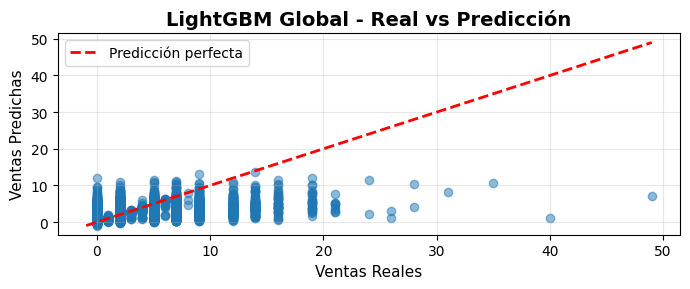

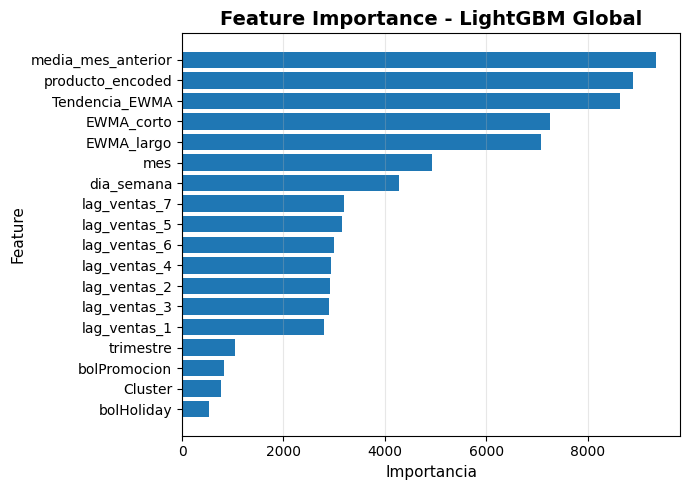

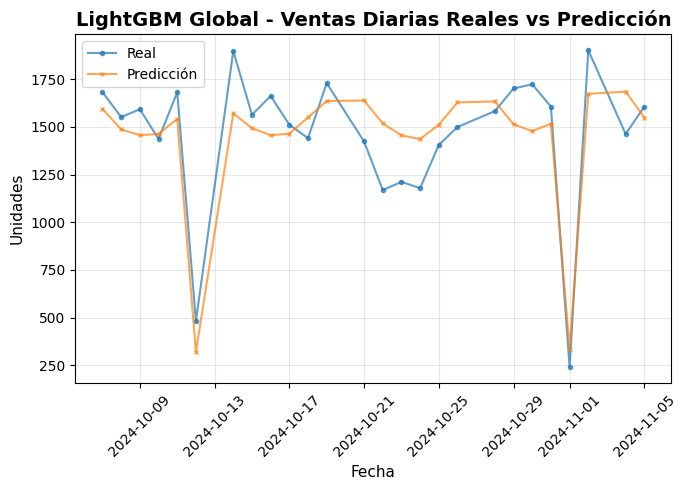

In [9]:

# Visualizaciones del modelo global
df_test_viz = df_test.copy()
df_test_viz['prediccion'] = y_test_pred
df_test_viz['error'] = y_test_pred - df_test_viz[TARGET]

grafico_scatter_prediccion(
    df=df_test_viz,
    col_real=TARGET,
    col_pred='prediccion',
    titulo='LightGBM Global - Real vs Predicción',
    figsize=(7, 3)
)

grafico_feature_importance(
    modelo=best_lgb,
    feature_names=FEATURES,
    top_n=len(FEATURES),
    titulo='Feature Importance - LightGBM Global',
    figsize=(7, 5)
)

# Crear dataframe con suma por día
df_daily = df_test_viz.copy()
df_daily['fecha'] = df_daily['idSecuencia'].dt.date
df_daily_sum = df_daily.groupby('fecha')[[TARGET, 'prediccion']].sum().reset_index()
grafico_real_vs_prediccion(
    df=df_daily_sum,
    col_real=TARGET,
    col_pred='prediccion',
    col_fecha='fecha',
    titulo='LightGBM Global - Ventas Diarias Reales vs Predicción',
    figsize=(7, 5)
)


# LightGBM por Cluster


🔍 MODELO 2: LIGHTGBM POR CLUSTER

🔄 Entrenando modelo para Cluster 0...
   ✓ MAE: 1.80 | RMSE: 2.54 | R²: 0.1201
   ✓ MAE: 1.80 | RMSE: 2.54 | R²: 0.1201


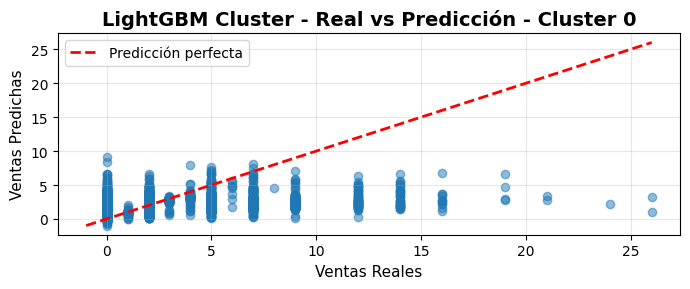

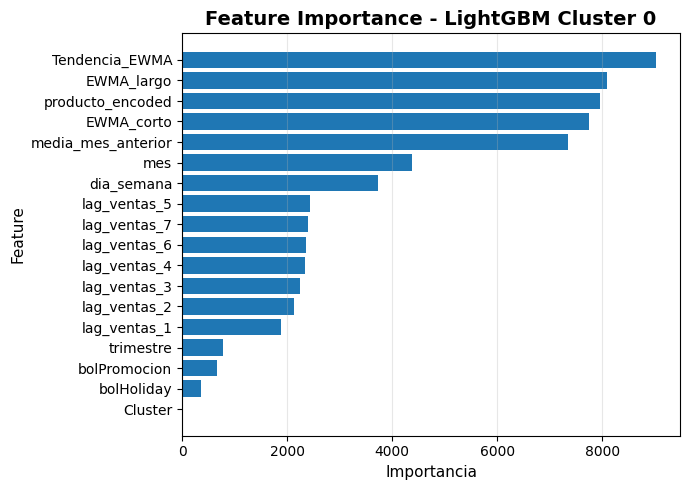

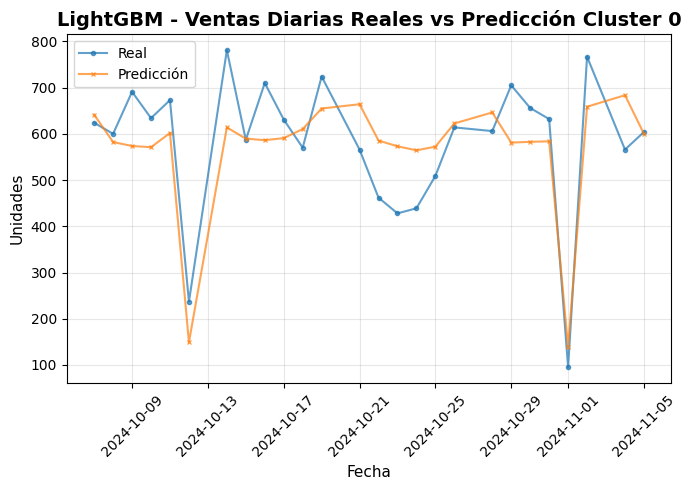


   📌 Producto representativo: 17 (26 registros)
   📊 Estadísticas del error:
      Error medio:             -0.04
      Error abs medio:          1.80
      Error máximo:            24.94


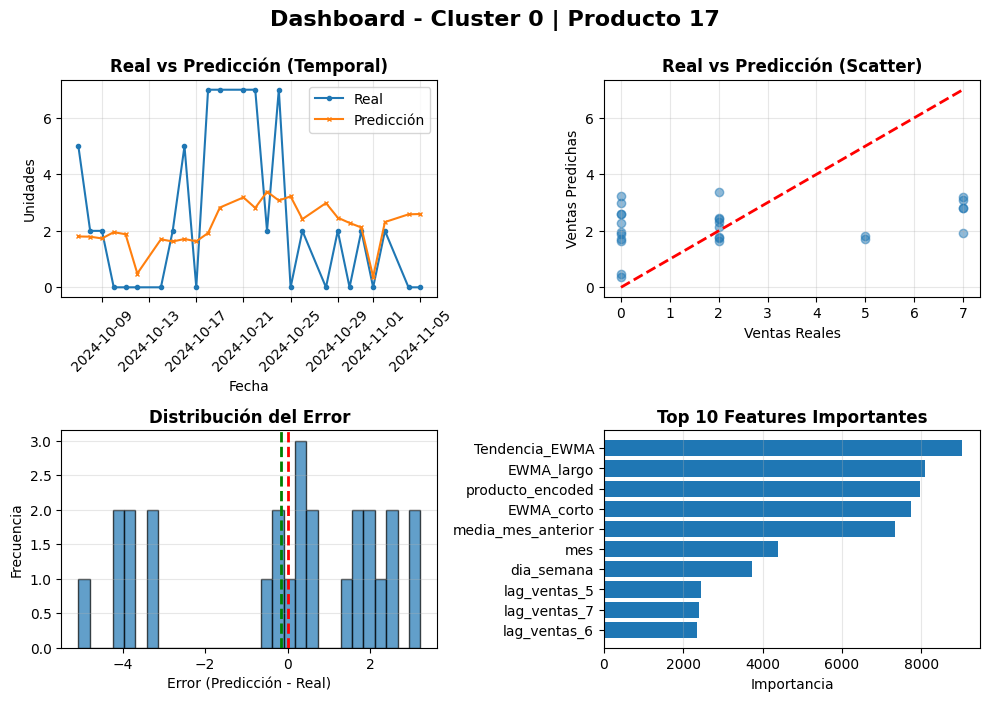


🔄 Entrenando modelo para Cluster 1...
   ✓ MAE: 2.78 | RMSE: 3.60 | R²: 0.1362
   ✓ MAE: 2.78 | RMSE: 3.60 | R²: 0.1362


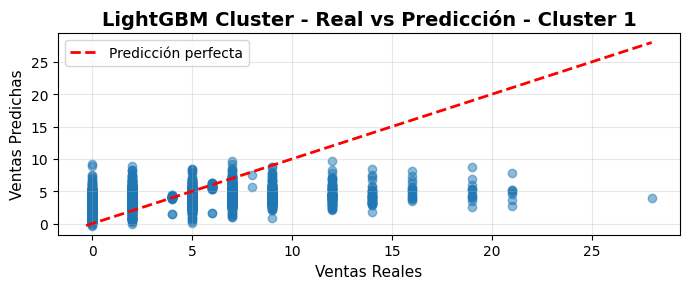

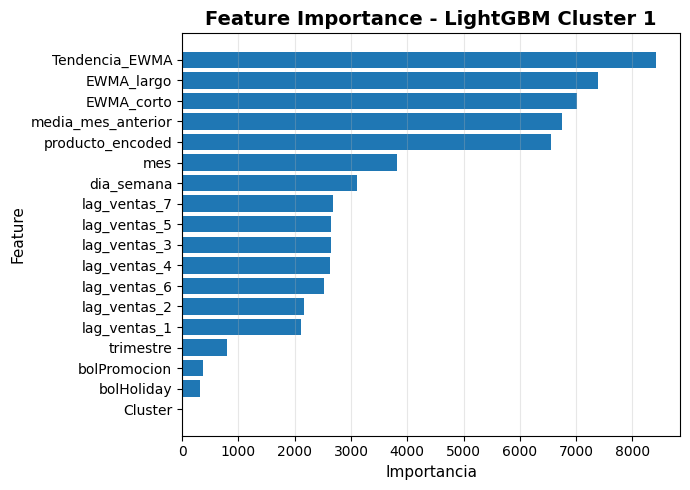

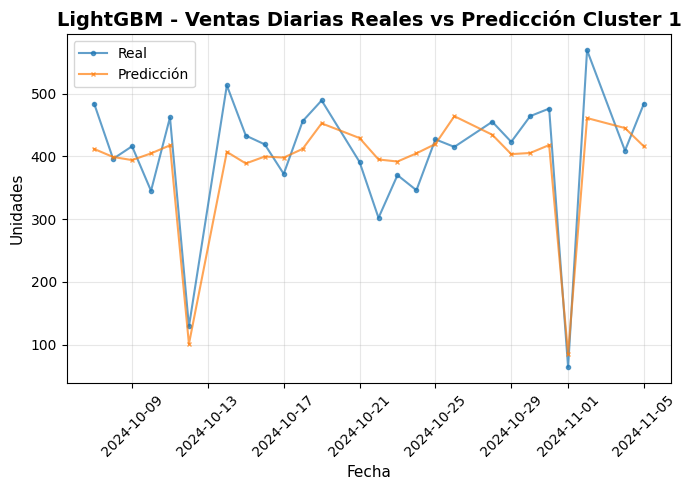


   📌 Producto representativo: 4 (26 registros)
   📊 Estadísticas del error:
      Error medio:             -0.13
      Error abs medio:          2.78
      Error máximo:            24.08


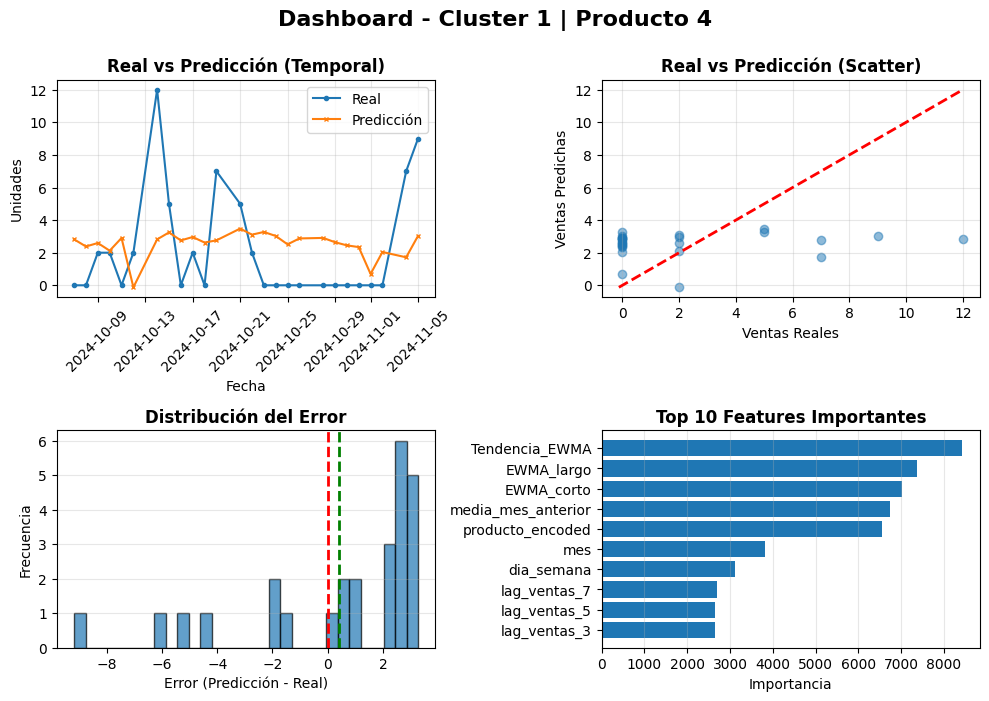


🔄 Entrenando modelo para Cluster 2...
   ✓ MAE: 3.67 | RMSE: 5.17 | R²: 0.1754
   ✓ MAE: 3.67 | RMSE: 5.17 | R²: 0.1754


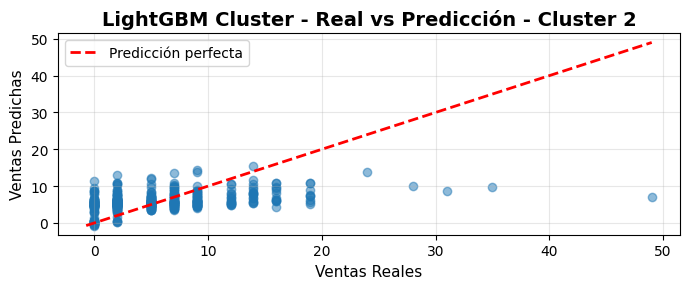

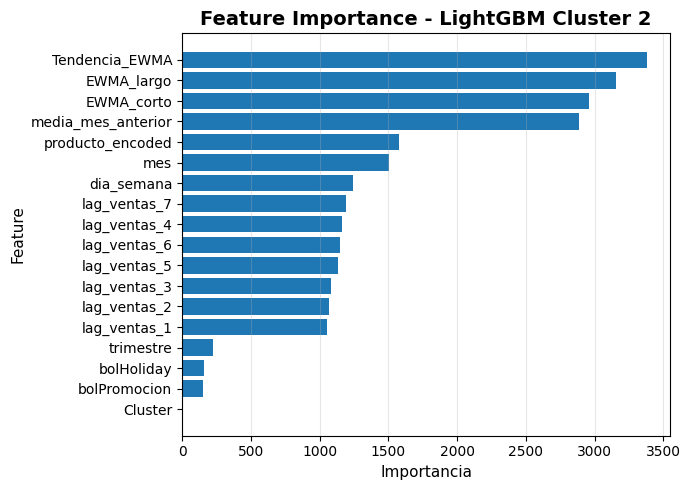

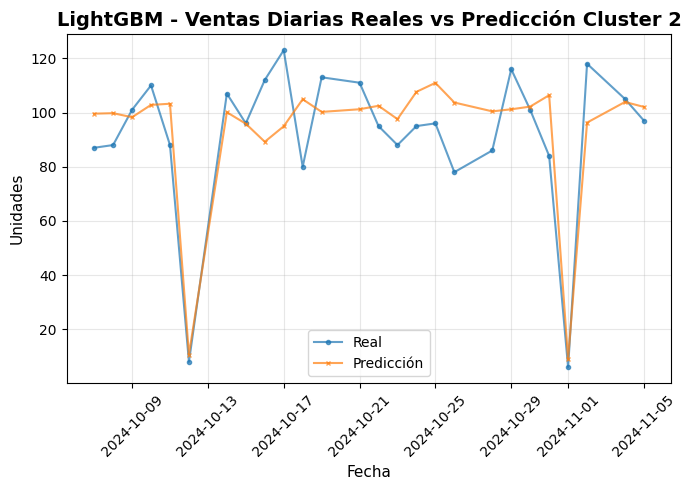


   📌 Producto representativo: 1 (26 registros)
   📊 Estadísticas del error:
      Error medio:              0.13
      Error abs medio:          3.67
      Error máximo:            41.82


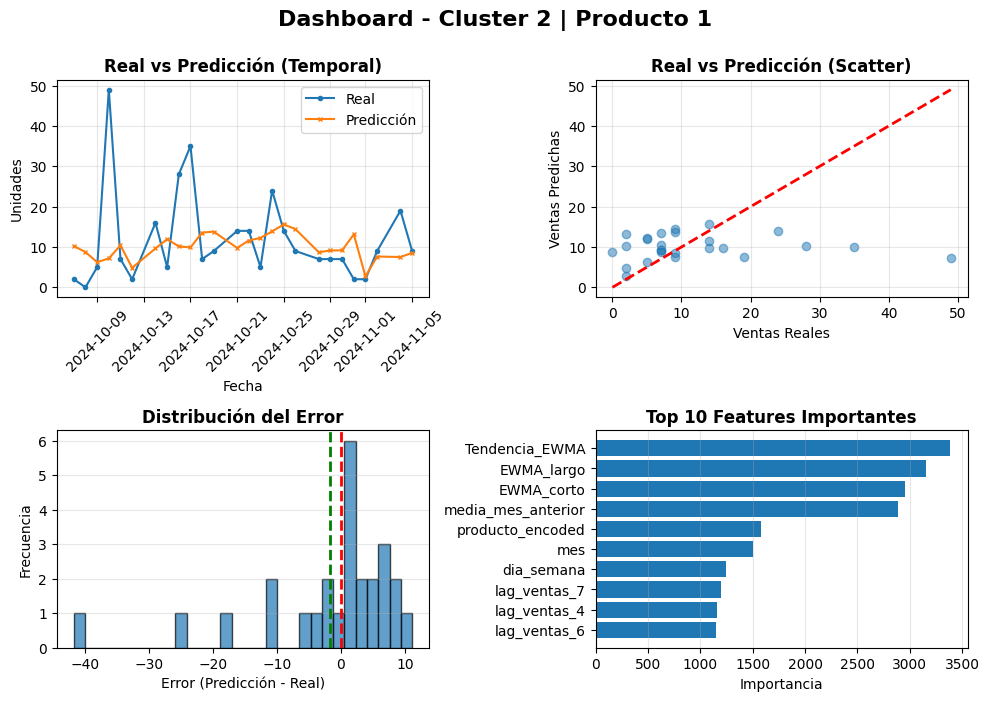


🔄 Entrenando modelo para Cluster 3...
   ✓ MAE: 1.09 | RMSE: 1.67 | R²: 0.0669
   ✓ MAE: 1.09 | RMSE: 1.67 | R²: 0.0669


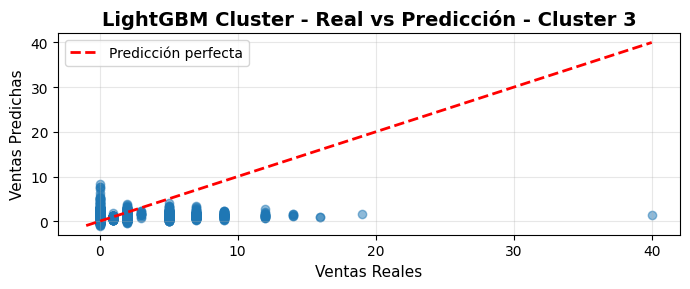

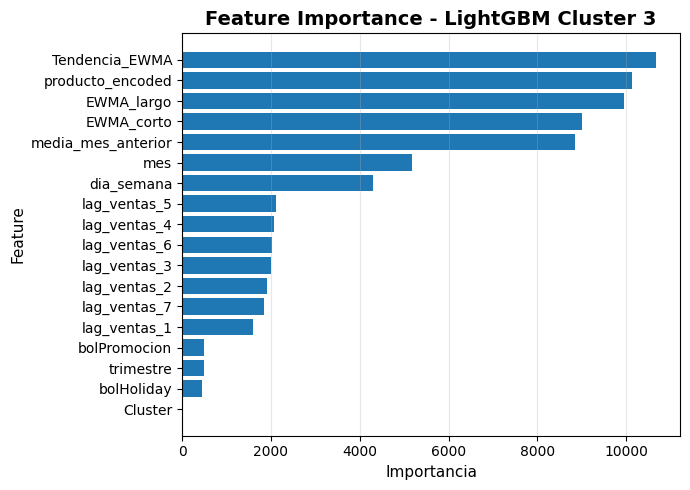

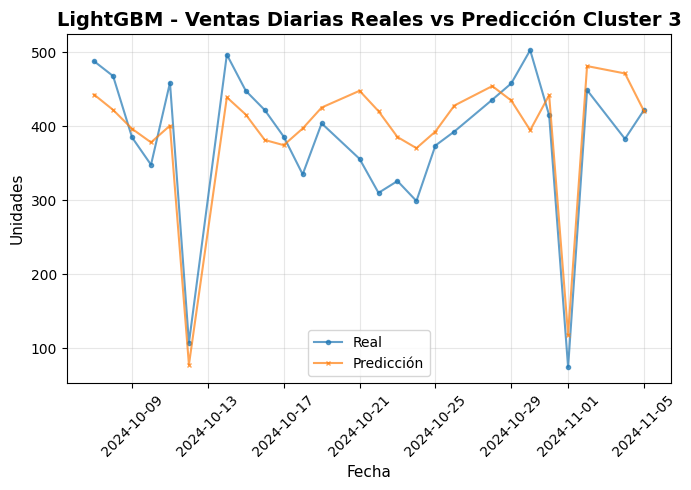


   📌 Producto representativo: 38 (26 registros)
   📊 Estadísticas del error:
      Error medio:              0.02
      Error abs medio:          1.09
      Error máximo:            38.64


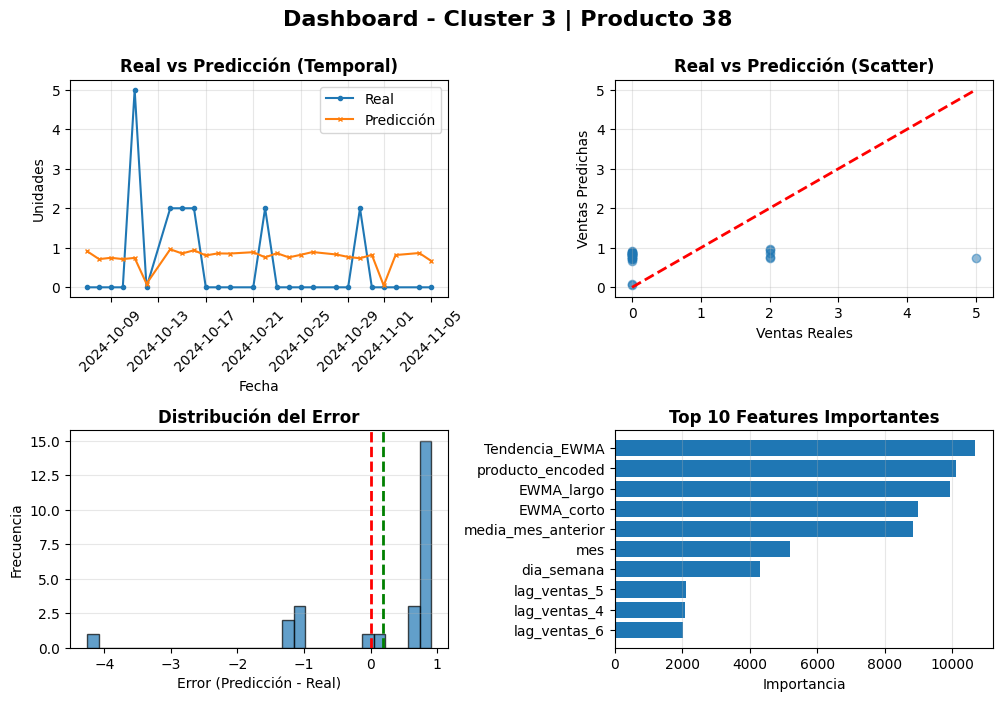

In [10]:
# ============================================================================
# 2. MODELOS POR CLUSTER
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 2: LIGHTGBM POR CLUSTER")
print("="*100)

modelos_cluster = {}

for cluster in sorted(df_train['Cluster'].unique()):
    print(f"\n🔄 Entrenando modelo para Cluster {cluster}...")
    
    # Filtrar datos
    train_cluster = df_train[df_train['Cluster'] == cluster]
    test_cluster = df_test[df_test['Cluster'] == cluster].dropna()
    
    if len(test_cluster) == 0:
        print(f"   ⚠️  No hay datos de validación")
        continue
    
    X_train_c = train_cluster[FEATURES]
    y_train_c = train_cluster[TARGET]
    X_test_c = test_cluster[FEATURES]
    y_test_c = test_cluster[TARGET]
      
    # Entrenar
        
    lgb_cluster = lgb.LGBMRegressor(**best_params)
    
    lgb_cluster.fit(X_train_c, y_train_c)
    y_pred_c = lgb_cluster.predict(X_test_c)
    
    # Calcular métricas
    metricas_cluster = calcular_metricas(y_test_c, y_pred_c, f"LightGBM Cluster {cluster}")
    todas_metricas.append(metricas_cluster)
    
    print(f"   ✓ MAE: {metricas_cluster['MAE']:.2f} | RMSE: {metricas_cluster['RMSE']:.2f} | R²: {metricas_cluster['R2']:.4f}")
    
    # Visualizaciones del modelo cluster
    df_test_viz = test_cluster.copy()
    df_test_viz['prediccion'] = y_pred_c
    df_test_viz['error'] = y_pred_c - df_test_viz[TARGET]

    grafico_scatter_prediccion(
        df=df_test_viz,
        col_real=TARGET,
        col_pred='prediccion',
        titulo=f'LightGBM Cluster - Real vs Predicción - Cluster {cluster}',
        figsize=(7, 3)
    )

    grafico_feature_importance(
        modelo=lgb_cluster,
        feature_names=FEATURES,
        top_n=len(FEATURES),
        titulo=f'Feature Importance - LightGBM Cluster {cluster}',
        figsize=(7, 5)
    )

    # Crear dataframe con suma por día
    df_daily = df_test_viz.copy()
    df_daily['fecha'] = df_daily['idSecuencia'].dt.date
    df_daily_sum = df_daily.groupby('fecha')[[TARGET, 'prediccion']].sum().reset_index()
    grafico_real_vs_prediccion(
        df=df_daily_sum,
        col_real=TARGET,
        col_pred='prediccion',
        col_fecha='fecha',
        titulo=f'LightGBM - Ventas Diarias Reales vs Predicción Cluster {cluster}',
        figsize=(7, 5)
    )
    
    # Preparar datos para visualización de producto representativo
    test_cluster_pred = test_cluster.copy()
    test_cluster_pred['prediccion'] = y_pred_c
    test_cluster_pred['error'] = y_pred_c - test_cluster_pred[TARGET]
    test_cluster_pred['error_abs'] = np.abs(test_cluster_pred['error'])
    
    # Seleccionar producto representativo
    producto_rep = test_cluster['producto'].value_counts().index[0]
    df_producto = test_cluster_pred[test_cluster_pred['producto'] == producto_rep].copy()
    df_producto = df_producto.sort_values('idSecuencia')
    
    print(f"\n   📌 Producto representativo: {producto_rep} ({len(df_producto)} registros)")
    
    # Estadísticas
    print(f"   📊 Estadísticas del error:")
    print(f"      Error medio:          {test_cluster_pred['error'].mean():>8.2f}")
    print(f"      Error abs medio:      {test_cluster_pred['error_abs'].mean():>8.2f}")
    print(f"      Error máximo:         {test_cluster_pred['error_abs'].max():>8.2f}")
    
    dashboard_prediccion(
        df=df_producto,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=lgb_cluster,
        feature_names=FEATURES,
        titulo_principal=f'Dashboard - Cluster {cluster} | Producto {producto_rep}',
        figsize=(10, 7)
    )


# LightGBM por top 10 productos de ventas


🔍 MODELO 3: LIGHTGBM POR PRODUCTO (TOP 10)

🏆 Top 10 productos: [1, 2, 9, 78, 7, 13, 15, 391, 3, 131]

🔄 Entrenando modelo para Producto 1...
   ✓ MAE: 8.44 | RMSE: 12.16 | R²: -0.1920

   📌 Producto 1
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion    error  error_abs
    2024-10-07         2   11.658826 9.658826   9.658826
    2024-10-08         0    6.799543 6.799543   6.799543
    2024-10-09         5    7.566157 2.566157   2.566157

   📊 Estadísticas del error:
      Error medio:             -2.54
      Error abs medio:          8.44
      Error máximo:            42.66
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE      MSE    RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto 1 8.4439 147.9075 12.1617 -0.192    117.33      76.72 0.7657    71.51

🏆 Mejor modelo: LightGBM Producto 1 (RMSE: 12.1617)


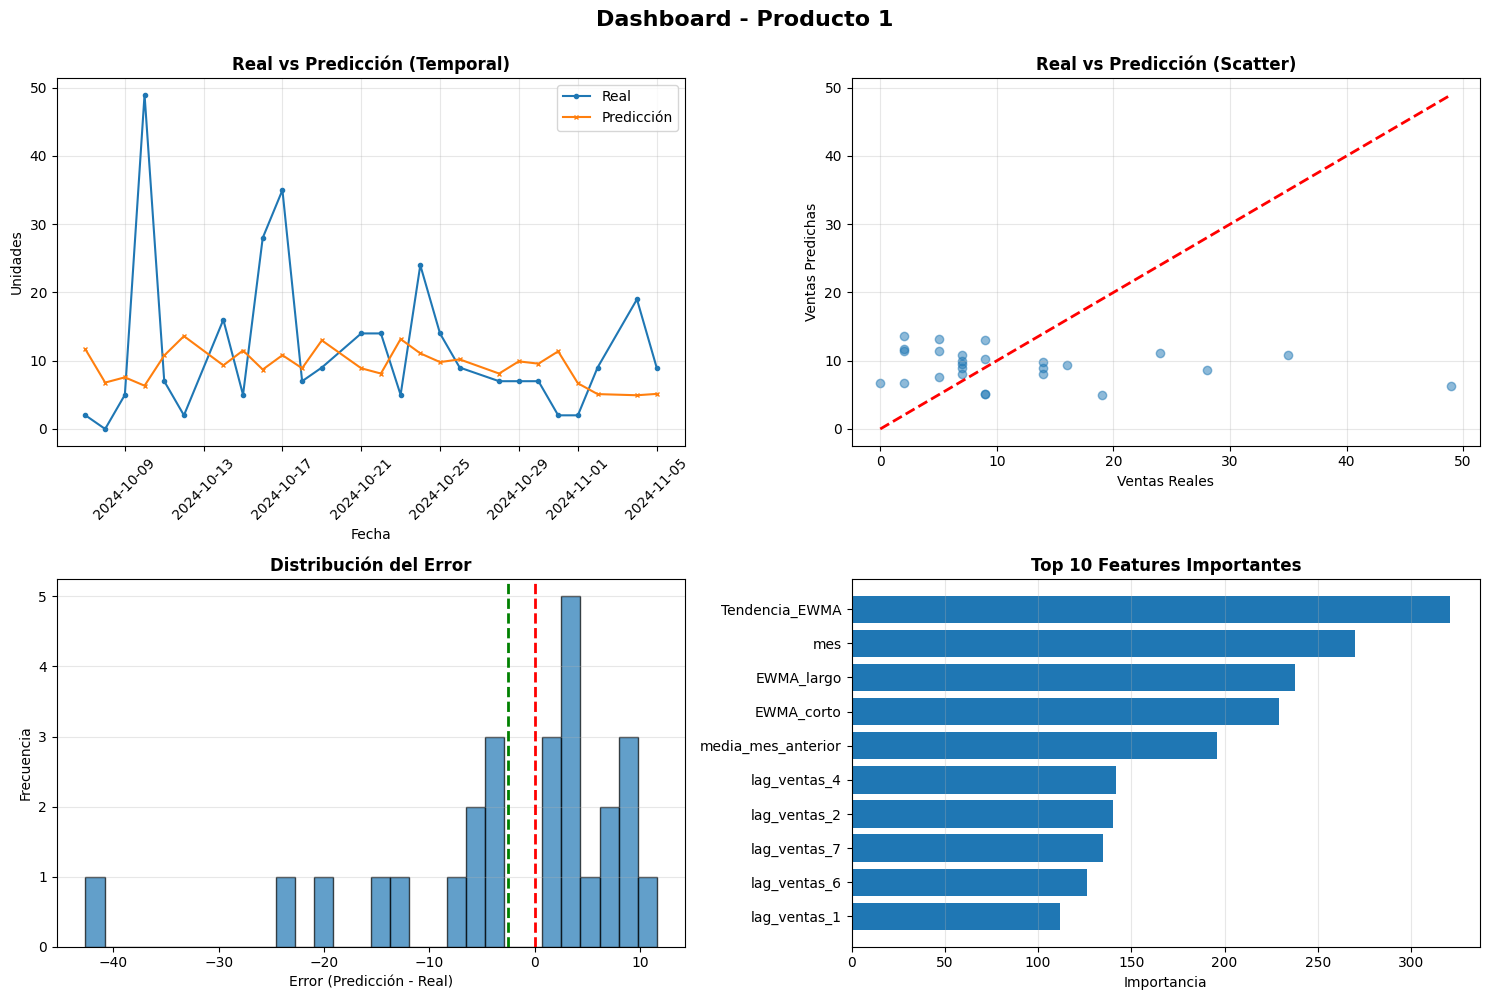


🔄 Entrenando modelo para Producto 2...
   ✓ MAE: 3.91 | RMSE: 4.96 | R²: -0.2048

   📌 Producto 2
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         7    7.302911  0.302911   0.302911
    2024-10-08         7    6.931715 -0.068285   0.068285
    2024-10-09        16    7.523899 -8.476101   8.476101

   📊 Estadísticas del error:
      Error medio:              1.39
      Error abs medio:          3.91
      Error máximo:             9.32
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto 2 3.9108 24.6297 4.9628 -0.2048     86.29      66.47 0.6895     62.0

🏆 Mejor modelo: LightGBM Producto 2 (RMSE: 4.9628)


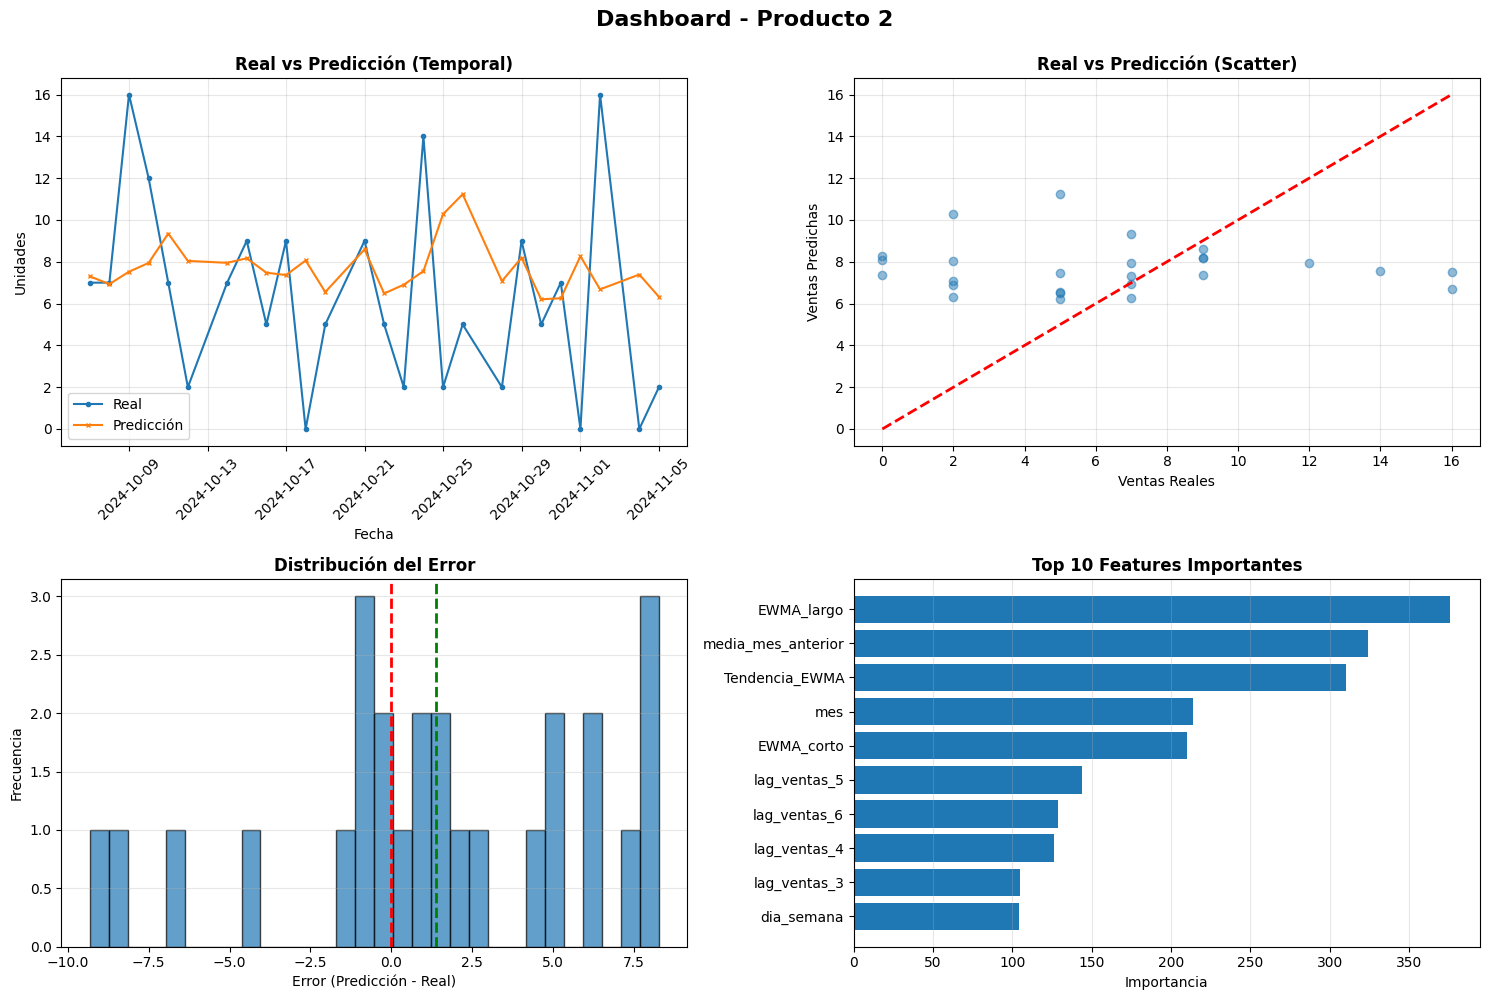


🔄 Entrenando modelo para Producto 9...
   ✓ MAE: 5.33 | RMSE: 5.96 | R²: -0.1553

   📌 Producto 9
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         9    6.008294 -2.991706   2.991706
    2024-10-08         2    7.670077  5.670077   5.670077
    2024-10-09         5    7.936639  2.936639   2.936639

   📊 Estadísticas del error:
      Error medio:              1.52
      Error abs medio:          5.33
      Error máximo:            10.00
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto 9 5.3253 35.563 5.9635 -0.1553     122.8      87.94 0.7966    82.91

🏆 Mejor modelo: LightGBM Producto 9 (RMSE: 5.9635)


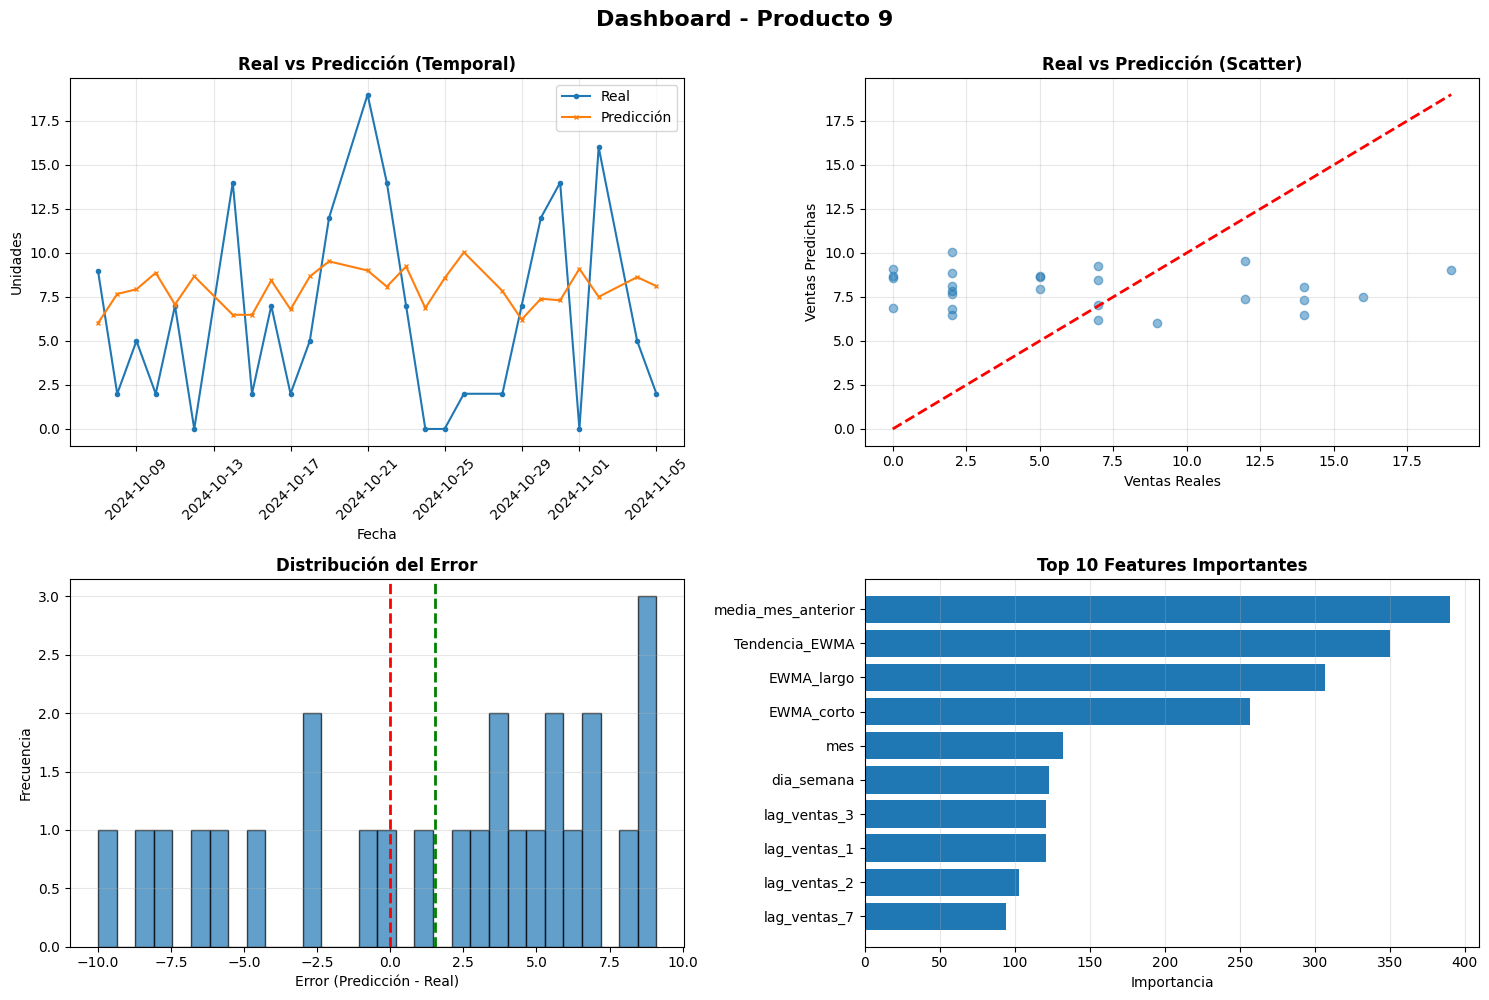


🔄 Entrenando modelo para Producto 78...
   ✓ MAE: 5.72 | RMSE: 7.12 | R²: 0.0120

   📌 Producto 78
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07        16    9.867183 -6.132817   6.132817
    2024-10-08        16    7.741457 -8.258543   8.258543
    2024-10-09        14   10.101765 -3.898235   3.898235

   📊 Estadísticas del error:
      Error medio:             -0.48
      Error abs medio:          5.72
      Error máximo:            20.16
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE    R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 78 5.7167 50.6743 7.1186 0.012     70.23      62.83 0.7082    50.56

🏆 Mejor modelo: LightGBM Producto 78 (RMSE: 7.1186)


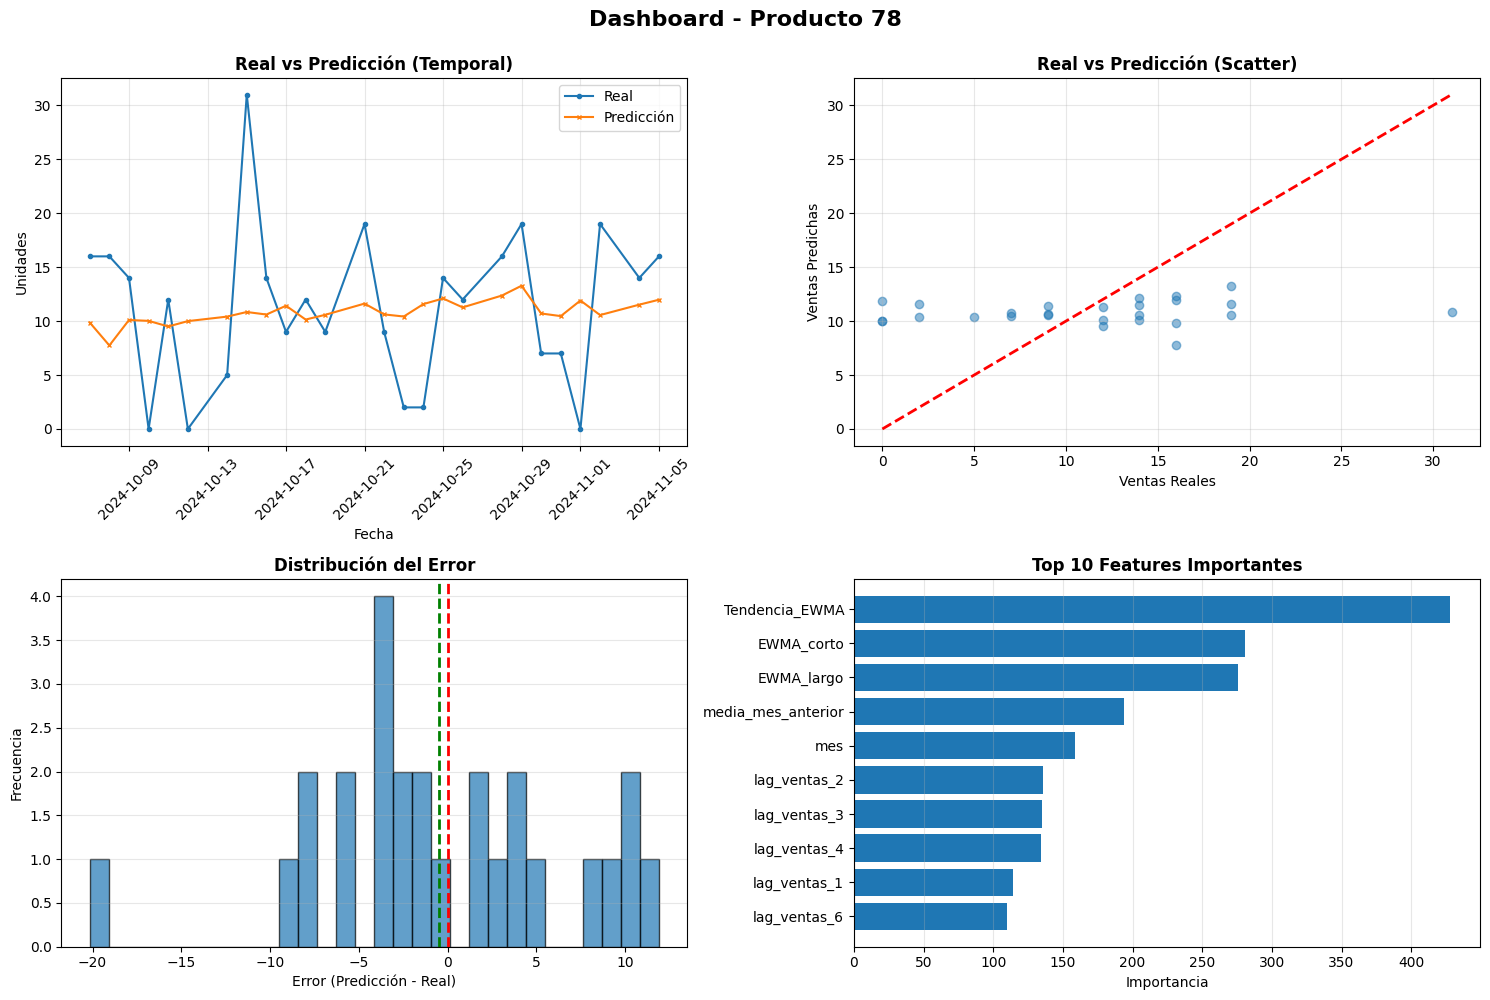


🔄 Entrenando modelo para Producto 7...
   ✓ MAE: 3.29 | RMSE: 3.69 | R²: -0.7642

   📌 Producto 7
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion    error  error_abs
    2024-10-07         0    5.358144 5.358144   5.358144
    2024-10-08         0    5.654440 5.654440   5.654440
    2024-10-09         0    4.650118 4.650118   4.650118

   📊 Estadísticas del error:
      Error medio:              2.31
      Error abs medio:          3.29
      Error máximo:             6.79
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto 7 3.2889 13.6023 3.6881 -0.7642      88.5     112.54 0.8987   129.56

🏆 Mejor modelo: LightGBM Producto 7 (RMSE: 3.6881)


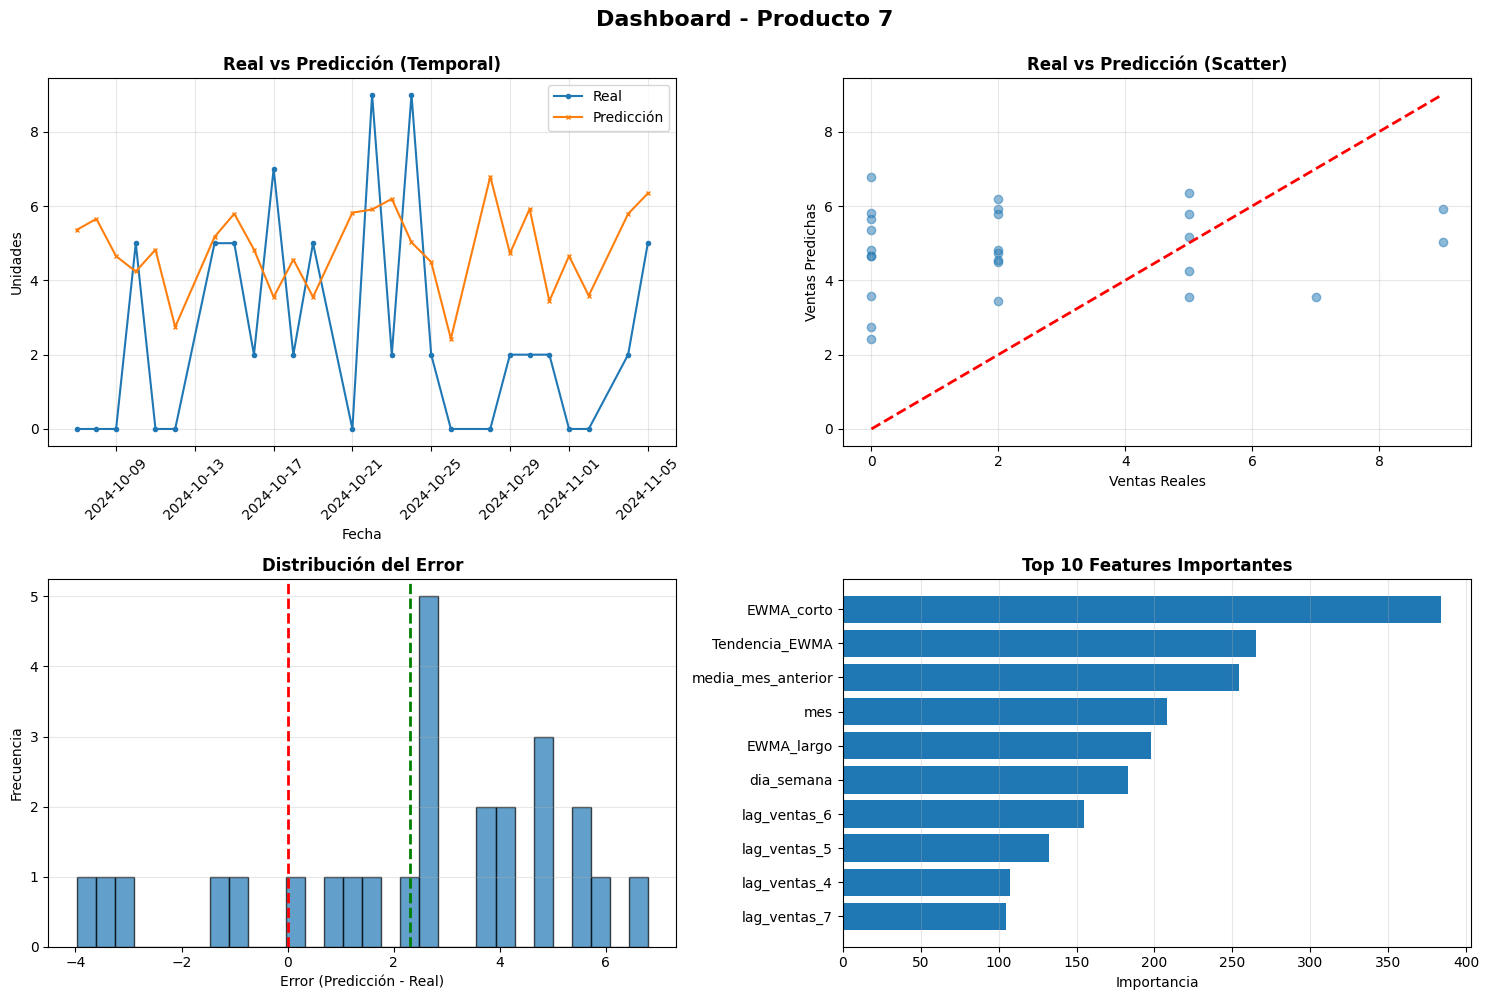


🔄 Entrenando modelo para Producto 13...
   ✓ MAE: 3.42 | RMSE: 3.95 | R²: -0.3448

   📌 Producto 13
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion    error  error_abs
    2024-10-07         2    5.755423 3.755423   3.755423
    2024-10-08         2    5.725489 3.725489   3.725489
    2024-10-09         2    5.681060 3.681060   3.681060

   📊 Estadísticas del error:
      Error medio:              1.61
      Error abs medio:          3.42
      Error máximo:             9.14
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 13 3.4227 15.5671 3.9455 -0.3448    102.08      84.66 0.7543     86.4

🏆 Mejor modelo: LightGBM Producto 13 (RMSE: 3.9455)


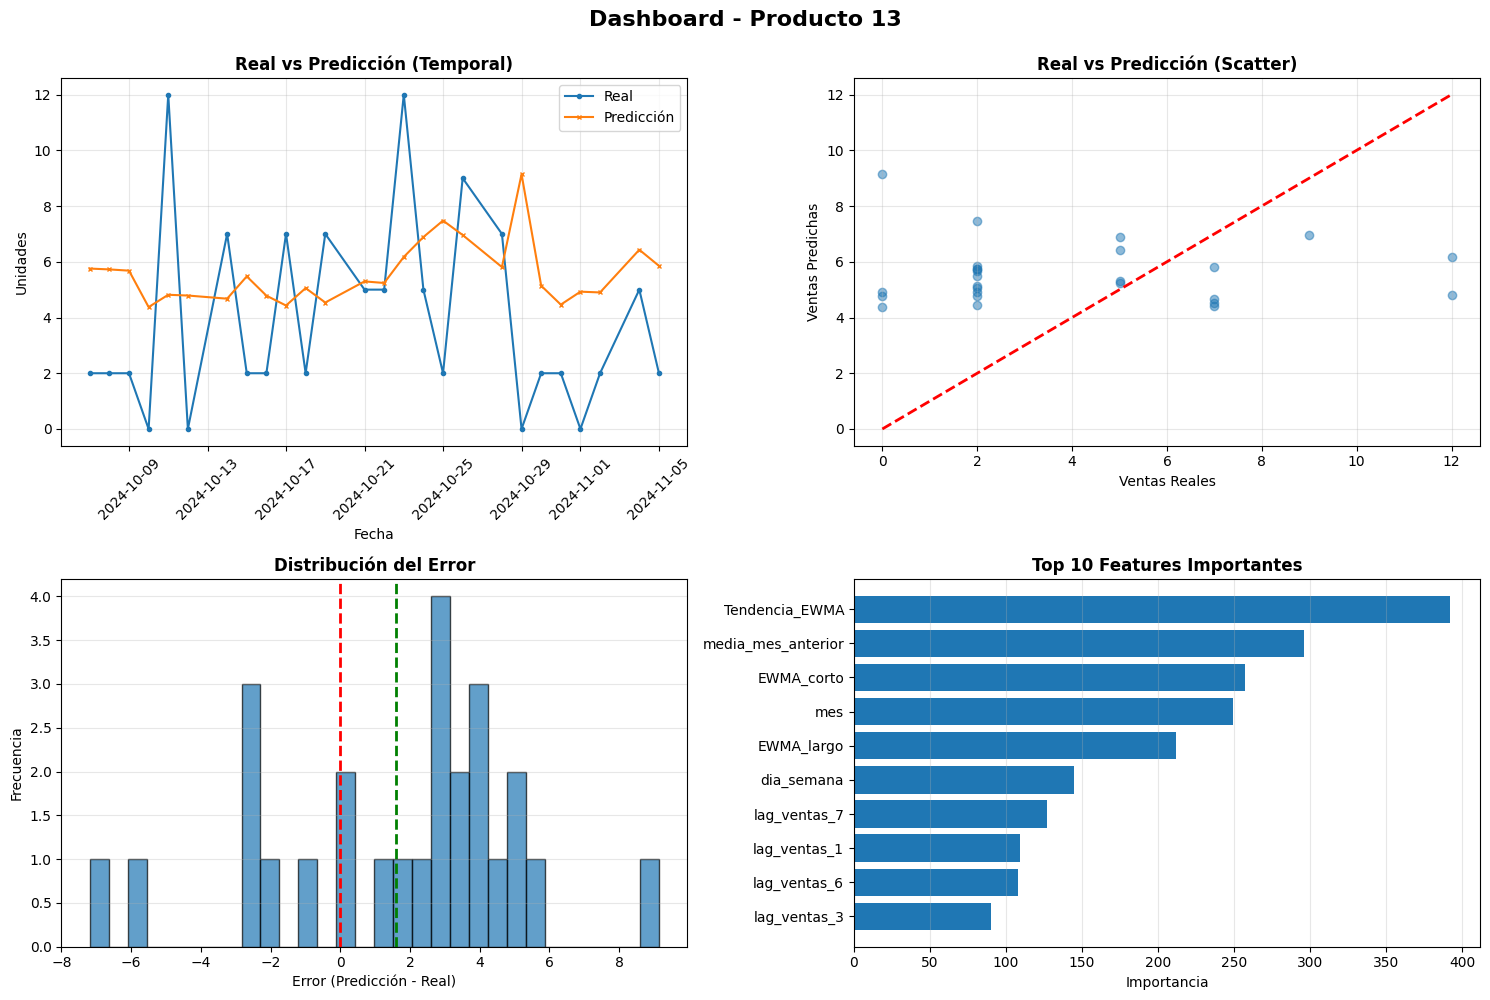


🔄 Entrenando modelo para Producto 15...
   ✓ MAE: 3.70 | RMSE: 4.44 | R²: -0.2339

   📌 Producto 15
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         7    6.120819 -0.879181   0.879181
    2024-10-08         5    5.404488  0.404488   0.404488
    2024-10-09         9    6.158789 -2.841211   2.841211

   📊 Estadísticas del error:
      Error medio:             -0.03
      Error abs medio:          3.70
      Error máximo:             8.35
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 15 3.7021 19.7197 4.4407 -0.2339     67.26      74.83 0.8508    65.04

🏆 Mejor modelo: LightGBM Producto 15 (RMSE: 4.4407)


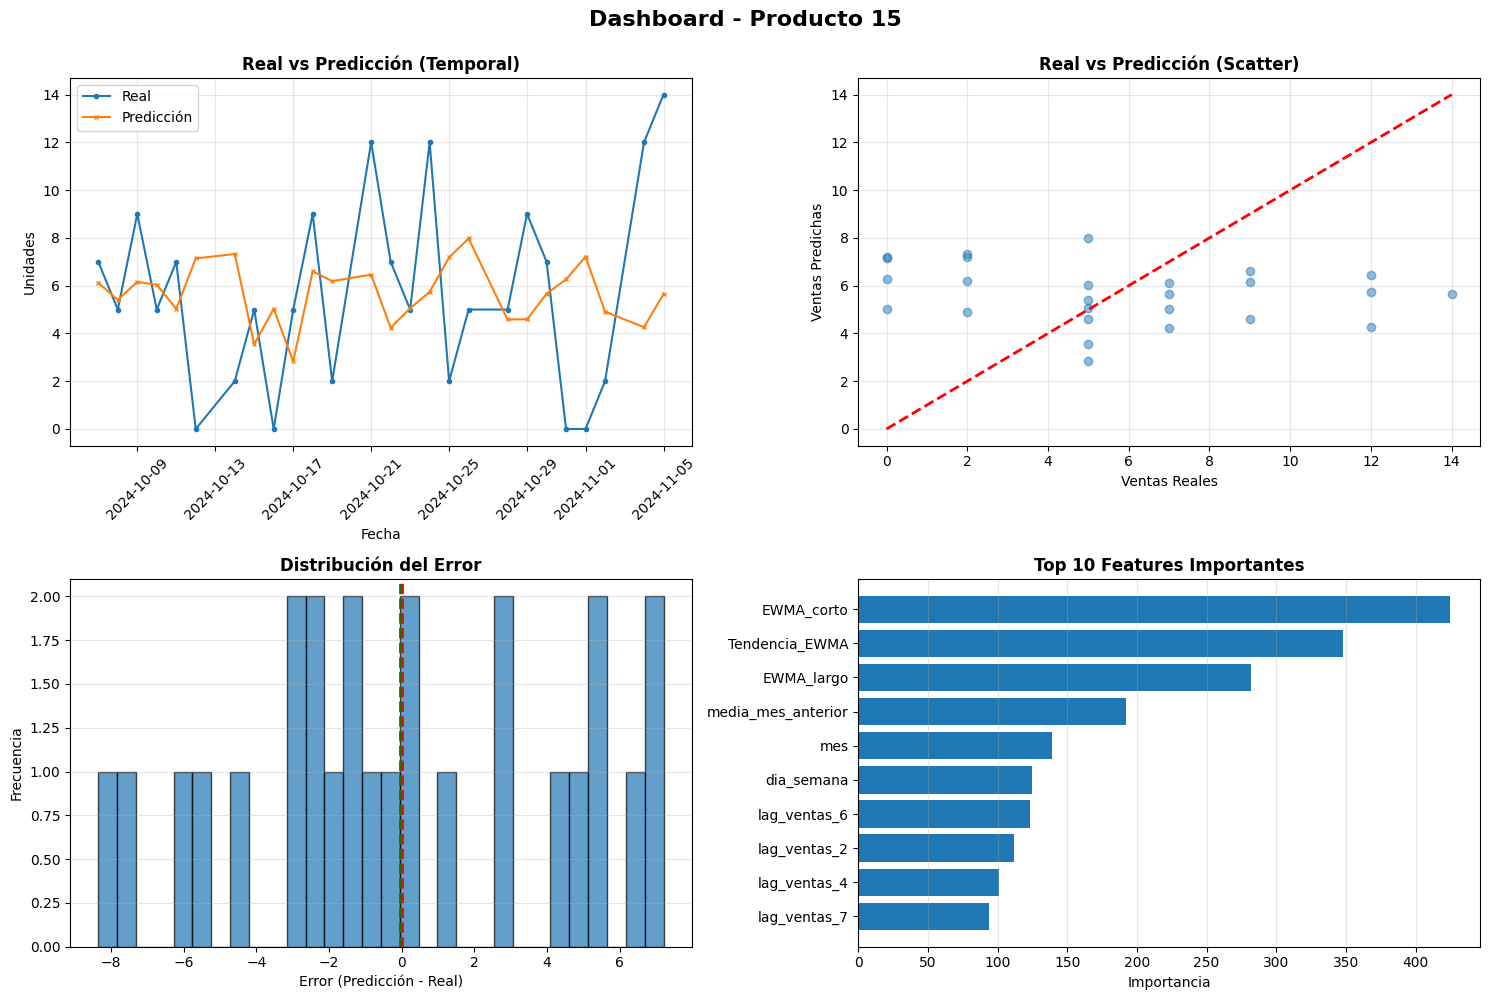


🔄 Entrenando modelo para Producto 391...
   ✓ MAE: 3.23 | RMSE: 3.93 | R²: -0.0899

   📌 Producto 391
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         5    5.641339  0.641339   0.641339
    2024-10-08         9    5.237569 -3.762431   3.762431
    2024-10-09         0    4.484371  4.484371   4.484371

   📊 Estadísticas del error:
      Error medio:              1.47
      Error abs medio:          3.23
      Error máximo:             9.91
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 391 3.2301 15.4333 3.9285 -0.0899     66.14     100.57 0.6993    95.43

🏆 Mejor modelo: LightGBM Producto 391 (RMSE: 3.9285)


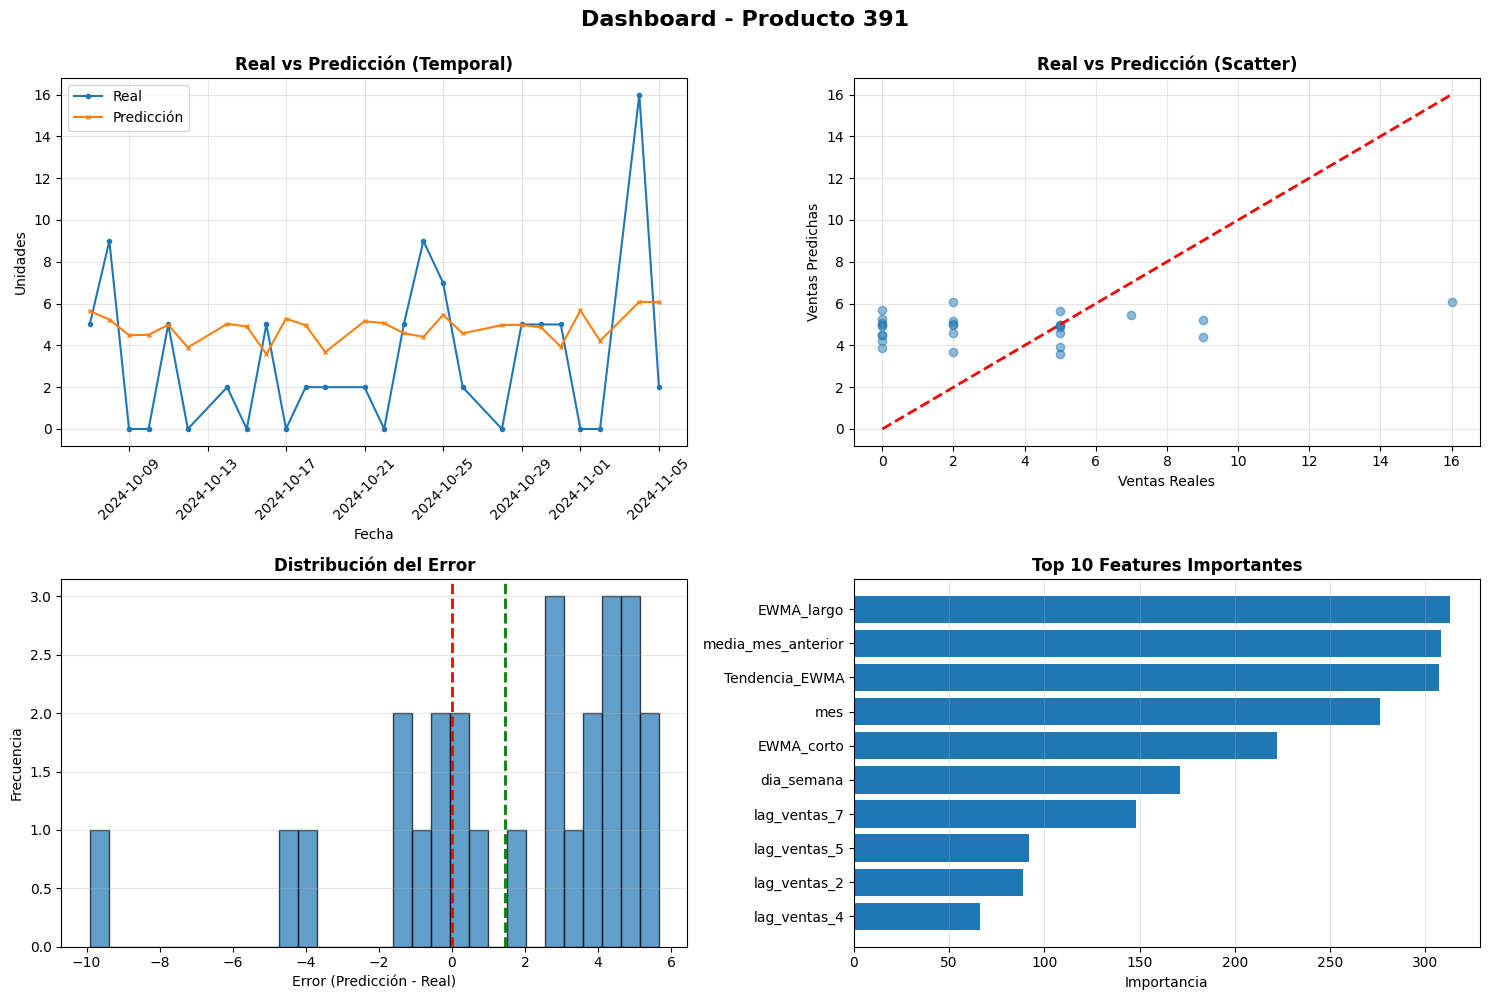


🔄 Entrenando modelo para Producto 3...
   ✓ MAE: 4.47 | RMSE: 5.73 | R²: -0.0832

   📌 Producto 3
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         7    5.154400 -1.845600   1.845600
    2024-10-08         5    2.994214 -2.005786   2.005786
    2024-10-09         5    3.422212 -1.577788   1.577788

   📊 Estadísticas del error:
      Error medio:             -0.55
      Error abs medio:          4.47
      Error máximo:            14.39
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE     MSE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto 3 4.4699 32.8432 5.7309 -0.0832     64.51      84.23 0.9715    69.59

🏆 Mejor modelo: LightGBM Producto 3 (RMSE: 5.7309)


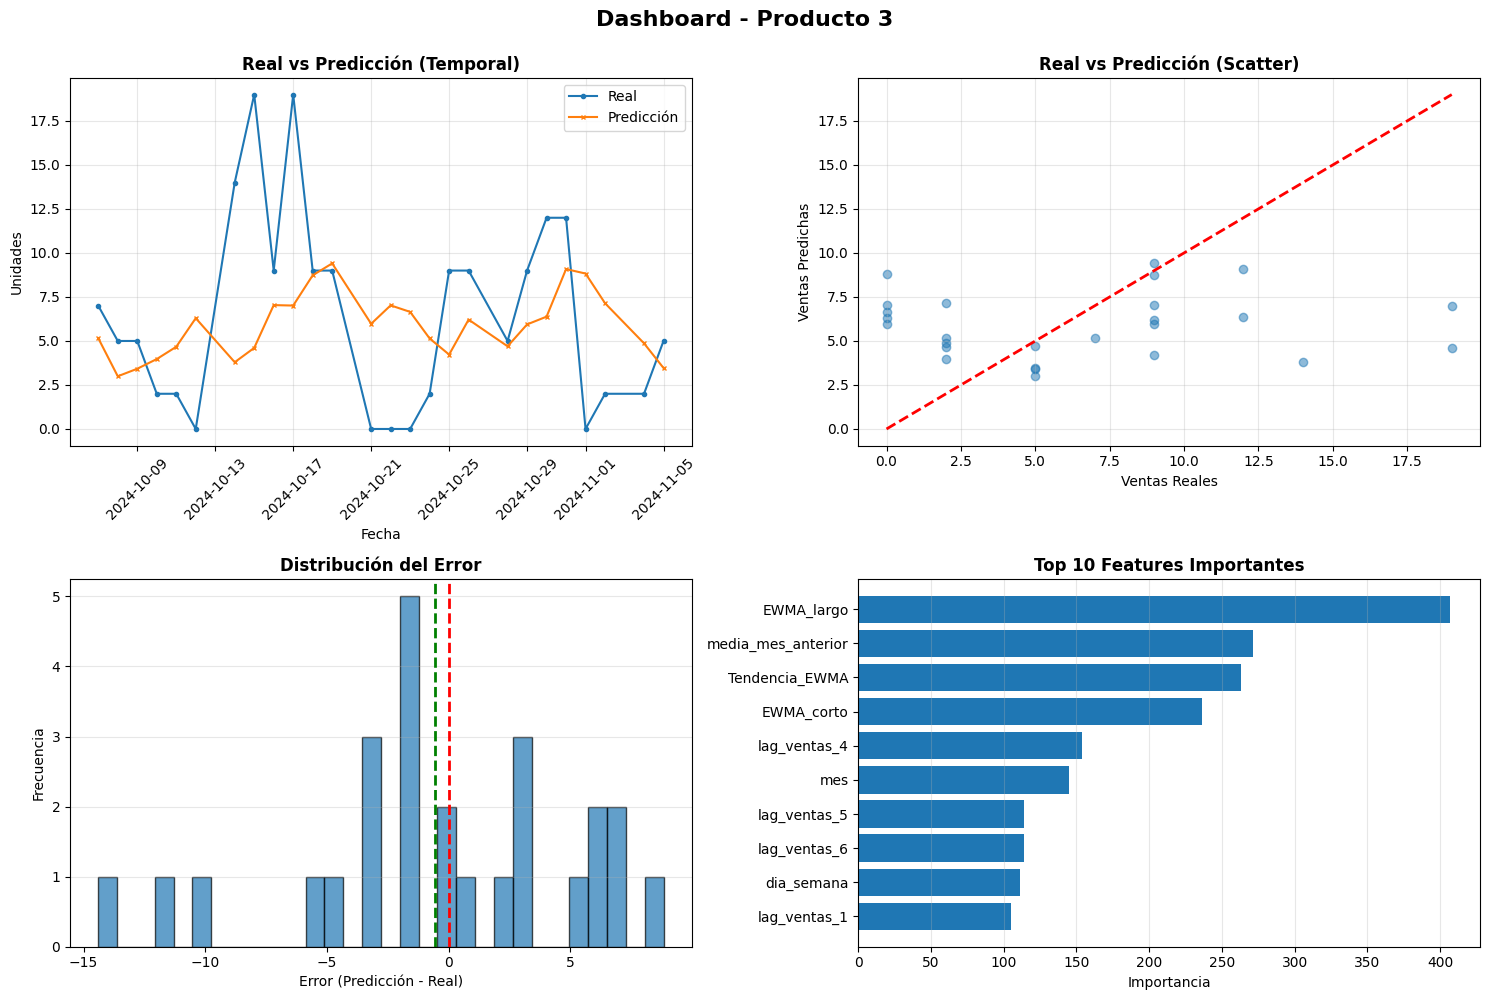


🔄 Entrenando modelo para Producto 131...
   ✓ MAE: 2.96 | RMSE: 3.51 | R²: 0.1747

   📌 Producto 131
      Train: 583 | Test: 26

   📋 Primeras 3 predicciones:
   idSecuencia  udsVenta  prediccion     error  error_abs
    2024-10-07         9    6.863172 -2.136828   2.136828
    2024-10-08         9    6.157690 -2.842310   2.842310
    2024-10-09         2    7.493339  5.493339   5.493339

   📊 Estadísticas del error:
      Error medio:              0.49
      Error abs medio:          2.96
      Error máximo:             6.33
      Error % medio:             inf%

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE     MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
LightGBM Producto 131 2.9589 12.2874 3.5053 0.1747     54.14      94.62 0.6917    79.31

🏆 Mejor modelo: LightGBM Producto 131 (RMSE: 3.5053)


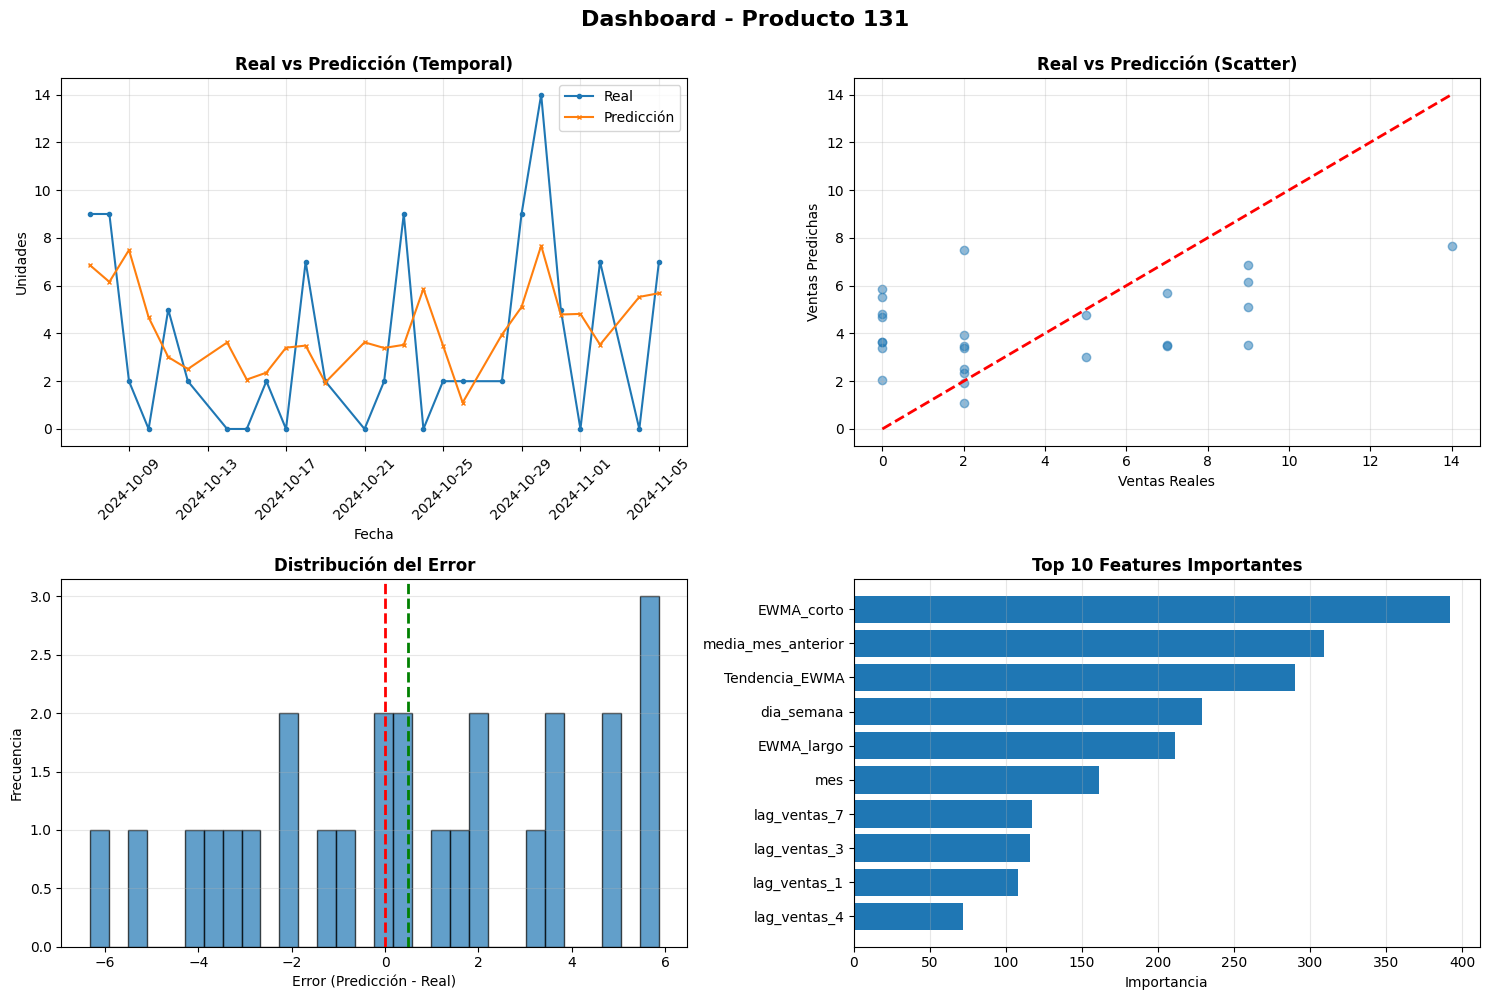

In [11]:
# ============================================================================
# 3. MODELOS POR PRODUCTO (TOP 10)
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 3: LIGHTGBM POR PRODUCTO (TOP 10)")
print("="*100)

top_productos = df_train.groupby('producto')['udsVenta'].sum().nlargest(10).index.tolist()
print(f"\n🏆 Top 10 productos: {top_productos}")

modelos_producto = {}

for producto in top_productos:
    print(f"\n🔄 Entrenando modelo para Producto {producto}...")
    
    # Filtrar datos
    train_prod = df_train[df_train['producto'] == producto]
    test_prod = df_test[df_test['producto'] == producto].dropna()
    
    if len(test_prod) == 0:
        print(f"   ⚠️  No hay datos de validación")
        continue
    
    if len(train_prod) < 100:
        print(f"   ⚠️  Datos insuficientes ({len(train_prod)} registros)")
        continue
    
    X_train_p = train_prod[FEATURES]
    y_train_p = train_prod[TARGET]
    X_test_p = test_prod[FEATURES]
    y_test_p = test_prod[TARGET]
    
    # Entrenar
    lgb_producto = lgb.LGBMRegressor(**best_params)
    
    lgb_producto.fit(X_train_p, y_train_p)
    y_pred_p = lgb_producto.predict(X_test_p)
    
    modelos_producto[producto] = lgb_producto
    
    # Calcular métricas
    metricas_producto = calcular_metricas(y_test_p, y_pred_p, f"LightGBM Producto {producto}")
    todas_metricas.append(metricas_producto)
    
    print(f"   ✓ MAE: {metricas_producto['MAE']:.2f} | RMSE: {metricas_producto['RMSE']:.2f} | R²: {metricas_producto['R2']:.4f}")
    
    # Preparar datos
    test_prod_pred = test_prod.copy()
    test_prod_pred['prediccion'] = y_pred_p
    test_prod_pred['error'] = y_pred_p - test_prod_pred[TARGET]
    test_prod_pred['error_abs'] = np.abs(test_prod_pred['error'])
    test_prod_pred['error_pct'] = (test_prod_pred['error_abs'] / test_prod_pred[TARGET]) * 100
    test_prod_pred = test_prod_pred.sort_values('idSecuencia')
    
    print(f"\n   📌 Producto {producto}")
    print(f"      Train: {len(train_prod)} | Test: {len(test_prod_pred)}")
    
    # Primeras predicciones
    print(f"\n   📋 Primeras 3 predicciones:")
    cols = ['idSecuencia', TARGET, 'prediccion', 'error', 'error_abs']
    print("   " + test_prod_pred[cols].head(3).to_string(index=False).replace('\n', '\n   '))
    
    # Estadísticas
    print(f"\n   📊 Estadísticas del error:")
    print(f"      Error medio:          {test_prod_pred['error'].mean():>8.2f}")
    print(f"      Error abs medio:      {test_prod_pred['error_abs'].mean():>8.2f}")
    print(f"      Error máximo:         {test_prod_pred['error_abs'].max():>8.2f}")
    print(f"      Error % medio:        {test_prod_pred['error_pct'].mean():>8.2f}%")
    
    if len(test_prod_pred) >= 2:
        resumen_metricas([metricas_producto])
        
        try:
            dashboard_prediccion(
                df=test_prod_pred,
                col_fecha='idSecuencia',
                col_real=TARGET,
                col_pred='prediccion',
                modelo=lgb_producto,
                feature_names=FEATURES,
                titulo_principal=f'Dashboard - Producto {producto}',
                figsize=(15, 10),
            )
        except Exception as e:
            print(f"   ⚠️  Error en dashboard: {str(e)}")


# Resumen final


🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS

📊 Resumen de todas las métricas:

📊 RESUMEN DE MÉTRICAS
            Algoritmo    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
   LightGBM Cluster 3 1.0852   2.7848  1.6688  0.0669     56.04     169.32 0.7488   133.63
 LightGBM Global Test 1.5656   5.6004  2.3665  0.2692     49.60     144.55 0.7252    95.88
   LightGBM Cluster 0 1.7964   6.4770  2.5450  0.1201     39.84     125.86 0.7316    93.03
LightGBM Producto 131 2.9589  12.2874  3.5053  0.1747     54.14      94.62 0.6917    79.31
   LightGBM Cluster 1 2.7849  12.9862  3.6036  0.1362     56.03      98.97 0.7202    73.03
  LightGBM Producto 7 3.2889  13.6023  3.6881 -0.7642     88.50     112.54 0.8987   129.56
LightGBM Producto 391 3.2301  15.4333  3.9285 -0.0899     66.14     100.57 0.6993    95.43
 LightGBM Producto 13 3.4227  15.5671  3.9455 -0.3448    102.08      84.66 0.7543    86.40
 LightGBM Producto 15 3.7021  19.7197  4.4407 -0.2339     67.26      74.

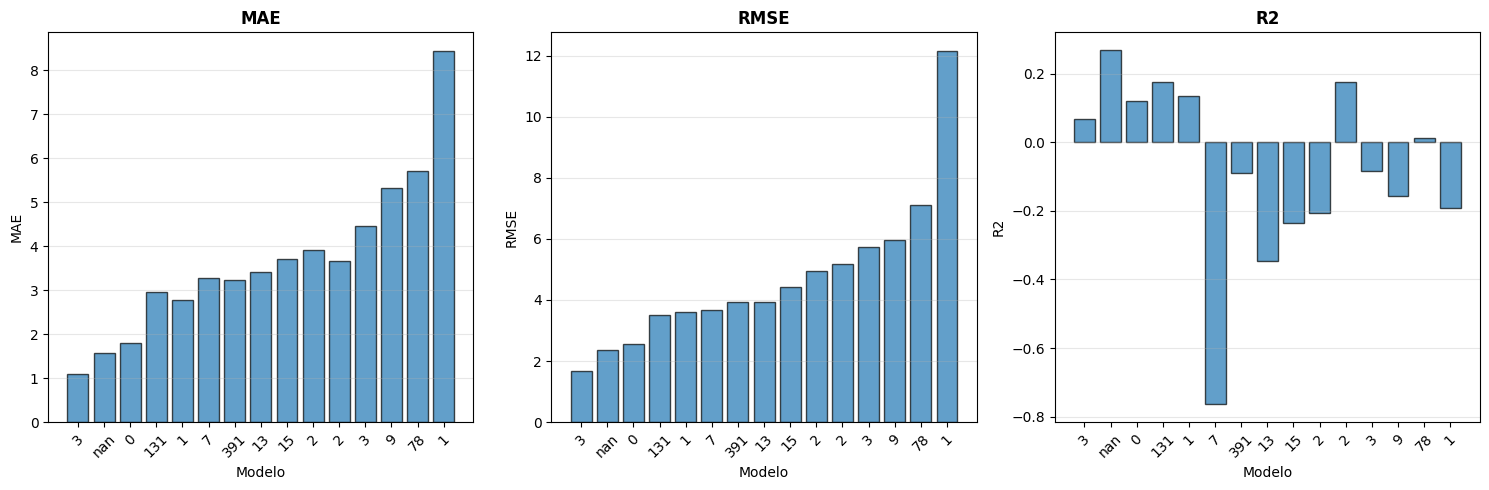


📊 ANÁLISIS POR CATEGORÍAS DE MODELOS

🌐 MODELOS GLOBALES:
           Algoritmo    MAE   RMSE     R2
LightGBM Global Test 1.5656 2.3665 0.2692

   Promedio RMSE: 2.37

🎯 MODELOS POR CLUSTER:
         Algoritmo    MAE   RMSE     R2
LightGBM Cluster 3 1.0852 1.6688 0.0669
LightGBM Cluster 0 1.7964 2.5450 0.1201
LightGBM Cluster 1 2.7849 3.6036 0.1362
LightGBM Cluster 2 3.6679 5.1656 0.1754

   Promedio RMSE: 3.25
   Mejor cluster: LightGBM Cluster 3 (RMSE: 1.67)
   Peor cluster: LightGBM Cluster 2 (RMSE: 5.17)

🛒 MODELOS POR PRODUCTO:
            Algoritmo    MAE    RMSE      R2
LightGBM Producto 131 2.9589  3.5053  0.1747
  LightGBM Producto 7 3.2889  3.6881 -0.7642
LightGBM Producto 391 3.2301  3.9285 -0.0899
 LightGBM Producto 13 3.4227  3.9455 -0.3448
 LightGBM Producto 15 3.7021  4.4407 -0.2339
  LightGBM Producto 2 3.9108  4.9628 -0.2048
  LightGBM Producto 3 4.4699  5.7309 -0.0832
  LightGBM Producto 9 5.3253  5.9635 -0.1553
 LightGBM Producto 78 5.7167  7.1186  0.0120
  LightGBM 

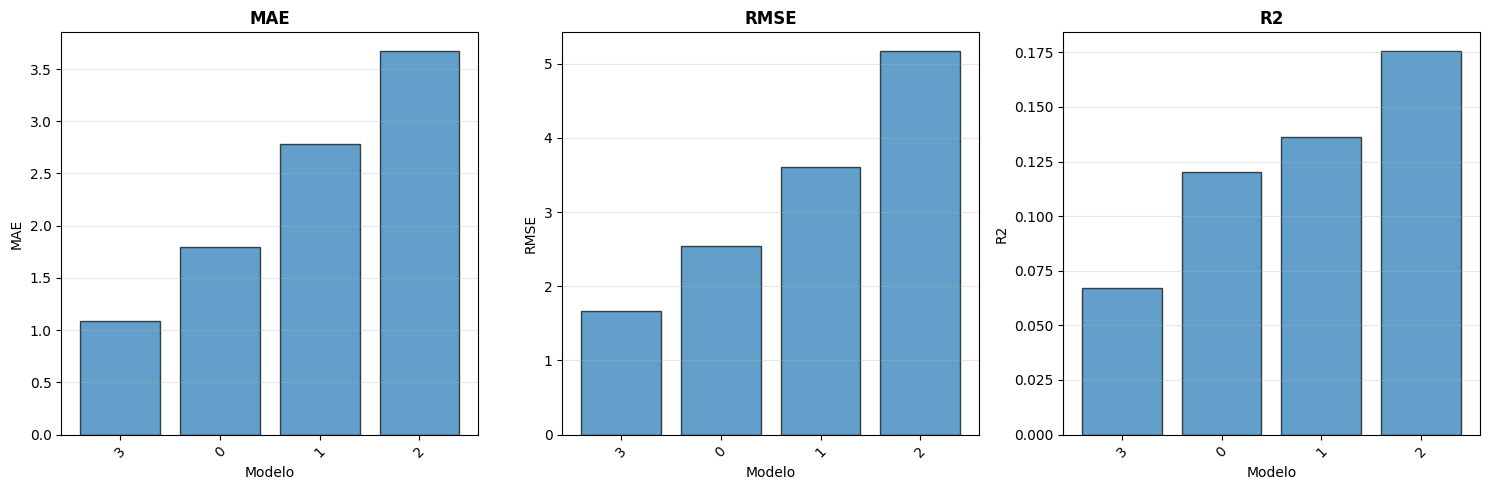


📊 Comparación entre productos:


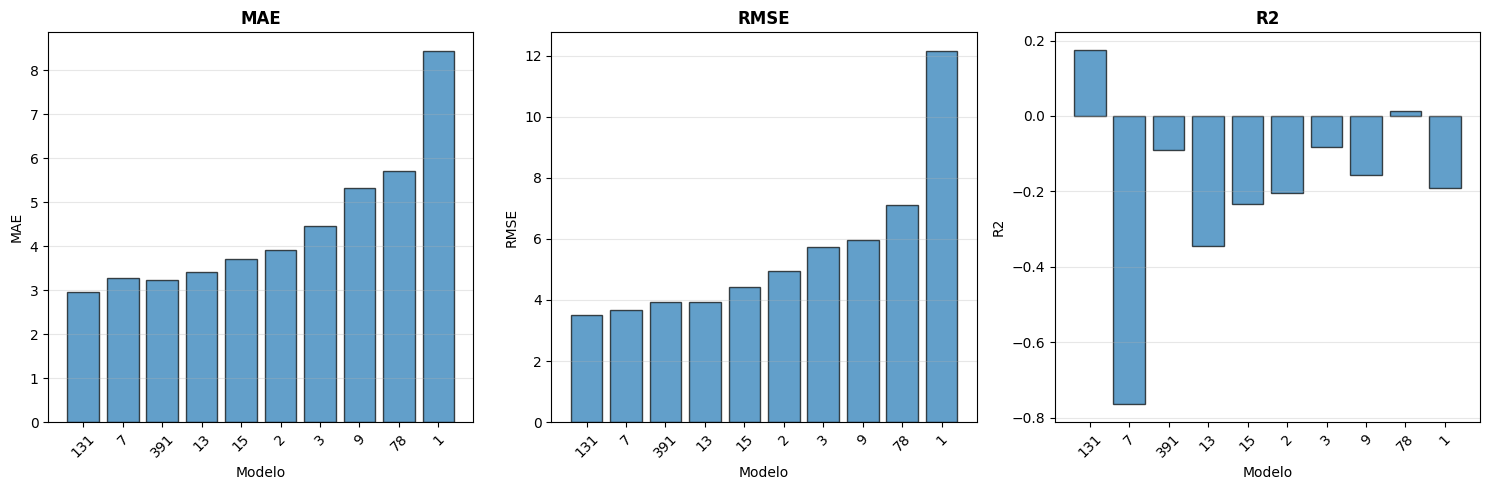


✅ ANÁLISIS COMPLETO FINALIZADO

📊 Total de modelos evaluados: 15
   - Modelos globales: 1
   - Modelos por cluster: 4
   - Modelos por producto: 10


In [12]:
# ============================================================================
# 4. RESUMEN FINAL DE TODOS LOS MODELOS
# ============================================================================

print("\n" + "="*100)
print("🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS")
print("="*100)

if todas_metricas:
    # Mostrar tabla completa de métricas
    print("\n📊 Resumen de todas las métricas:")
    resumen_metricas(todas_metricas)
    
    # Comparar métricas
    df_comparacion_final = comparar_metricas(todas_metricas, ordenar_por='RMSE')
    
    print("\n" + "="*100)
    print("📈 RANKING DE MODELOS POR RMSE")
    print("="*100)
    print(df_comparacion_final[['Algoritmo', 'MAE', 'RMSE', 'R2', 'MAPE (%)']].to_string(index=False))
    
    # Gráfico comparativo de TODOS los modelos
    print("\n📊 Generando gráficos comparativos...")
    grafico_comparacion_metricas(df_comparacion_final, metricas=['MAE', 'RMSE', 'R2'])
    
    # Análisis por categorías
    print("\n" + "="*100)
    print("📊 ANÁLISIS POR CATEGORÍAS DE MODELOS")
    print("="*100)
    
    # Separar por tipo de modelo
    df_global = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Global')]
    df_clusters = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Cluster')]
    df_productos = df_comparacion_final[df_comparacion_final['Algoritmo'].str.contains('Producto')]
    
    print("\n🌐 MODELOS GLOBALES:")
    if len(df_global) > 0:
        print(df_global[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_global['RMSE'].mean():.2f}")
    
    print("\n🎯 MODELOS POR CLUSTER:")
    if len(df_clusters) > 0:
        print(df_clusters[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_clusters['RMSE'].mean():.2f}")
        print(f"   Mejor cluster: {df_clusters.iloc[0]['Algoritmo']} (RMSE: {df_clusters.iloc[0]['RMSE']:.2f})")
        print(f"   Peor cluster: {df_clusters.iloc[-1]['Algoritmo']} (RMSE: {df_clusters.iloc[-1]['RMSE']:.2f})")
    
    print("\n🛒 MODELOS POR PRODUCTO:")
    if len(df_productos) > 0:
        print(df_productos[['Algoritmo', 'MAE', 'RMSE', 'R2']].to_string(index=False))
        print(f"\n   Promedio RMSE: {df_productos['RMSE'].mean():.2f}")
        print(f"   Mejor producto: {df_productos.iloc[0]['Algoritmo']} (RMSE: {df_productos.iloc[0]['RMSE']:.2f})")
        print(f"   Peor producto: {df_productos.iloc[-1]['Algoritmo']} (RMSE: {df_productos.iloc[-1]['RMSE']:.2f})")
    
    # Mejor modelo general
    print("\n" + "="*100)
    print("🥇 MEJOR MODELO GENERAL")
    print("="*100)
    mejor_idx = df_comparacion_final['RMSE'].idxmin()
    mejor_modelo = df_comparacion_final.loc[mejor_idx]
    
    print(f"\n🏆 {mejor_modelo['Algoritmo']}")
    print(f"   MAE:        {mejor_modelo['MAE']:.2f}")
    print(f"   RMSE:       {mejor_modelo['RMSE']:.2f}")
    print(f"   R²:         {mejor_modelo['R2']:.4f}")
    print(f"   MAPE:       {mejor_modelo['MAPE (%)']:.2f}%")
    print(f"   SMAPE:      {mejor_modelo['SMAPE (%)']:.2f}%")
    
    # Gráficos comparativos por categoría
    if len(df_clusters) > 1:
        print("\n📊 Comparación entre clusters:")
        grafico_comparacion_metricas(df_clusters, metricas=['MAE', 'RMSE', 'R2'])
    
    if len(df_productos) > 1:
        print("\n📊 Comparación entre productos:")
        grafico_comparacion_metricas(df_productos, metricas=['MAE', 'RMSE', 'R2'])
    
else:
    print("\n⚠️  No se generaron métricas para ningún modelo")

print("\n" + "="*100)
print("✅ ANÁLISIS COMPLETO FINALIZADO")
print("="*100)
print(f"\n📊 Total de modelos evaluados: {len(todas_metricas)}")
print(f"   - Modelos globales: {len([m for m in todas_metricas if 'Global' in m['Algoritmo']])}")
print(f"   - Modelos por cluster: {len([m for m in todas_metricas if 'Cluster' in m['Algoritmo']])}")
print(f"   - Modelos por producto: {len([m for m in todas_metricas if 'Producto' in m['Algoritmo']])}")

# Salvar resultados

In [13]:
# salvar resultados en fichero
df_resultados = pd.DataFrame(todas_metricas)
# Guardar con un nombre distintivo para LightGBM
df_resultados.to_csv('datos/resultados_metricas_lightgbm.csv', index=False)
print("Resultados guardados en 'datos/resultados_metricas_lightgbm.csv'")

Resultados guardados en 'datos/resultados_metricas_lightgbm.csv'
